# Assignment 2 — Regression and Classification: Error Analysis

**Holon Institute of Technology (HIT) — Faculty of Computer Science**

| | |
|---|---|
| **Course** | Introduction to Data Science |
| **Assignment** | 2 — Regression and Classification: Error Analysis |
| **Student name** | Sean Mazon |
| **ID number** | 212234660 |
| **Lecturer** | Dr. Uri Itai |
| **Teaching assistant** | Hanit Ohayon Hadad |
| **Submission deadline** | 10.09.2026 |

---

## Table of Contents

0. [Introduction](#0-introduction)
1. [Data Preparation](#1-data-preparation)
2. [Regression Error Analysis](#2-regression-error-analysis)
3. [Regression Models](#3-regression-models)
4. [Classification Error Analysis](#4-classification-error-analysis)
5. [Final Reflection](#5-final-reflection)

## 0. Introduction

This chapter sets out what the assignment asks for, what data the analysis is
built on, and which parts of the setup are prescribed by the assignment as
opposed to chosen here. It contains no code and no results; the analysis begins
in chapter 1.

### 0.1 Objective

The assignment defines its own purpose as developing an understanding of
regression and classification models **through systematic error analysis**, and
asks students to distinguish between failures that arise from data issues, from
model assumptions, and from how the problem was formulated.

That framing determines how this notebook is written. **Predictive accuracy is
not the goal.** A model that scored well but whose errors could not be
explained would fail the assignment, while a model that performs modestly and
whose failures are understood would satisfy it. Every metric reported here
exists to support a statement about *why* the model is wrong where it is wrong.

The assignment prescribes four things, and they are the fixed points of this
notebook:

1. The four analytical sections and their sub-tasks — residual analysis, error
   as a function of features, extreme errors, statistical properties of errors,
   the regression model comparison, the classification error analysis, and the
   final reflection.
2. Three families of regression model: linear, decision tree, and at least one
   ensemble.
3. That **all analyses be conducted using k-fold cross-validation**.
4. That the choice of *k* be justified in terms of dataset size, computational
   complexity, and the bias–variance trade-off.

Everything else — which dataset, which target variables, which features, which
classifiers — is not specified by the assignment. Those are decisions taken
here, and each one is identified as such and justified where it is made.

### 0.2 Dataset Overview

The assignment does not supply or name a dataset. This analysis continues with
the dataset used in Assignment 1: **1,500 of the highest-revenue games released
on Steam during 2024**, obtained from Kaggle and extracted on 2024-09-09. The
file holds 1,500 rows and 11 columns, mixing numeric, temporal and categorical
variables.

Using the same data is a deliberate choice. Assignment 1 established a set of
findings about its structure that directly constrain any model built on it, and
carrying those forward is more informative than rediscovering them:

| Finding from Assignment 1 | Consequence for this assignment |
|---|---|
| `reviewScore = 0` is a placeholder in 99 rows, `avgPlaytime = 0` in one | Must become missing values, then be imputed **inside** the cross-validation folds |
| `revenue` is extremely heavy-tailed (skew 22.9; 1.19 after a log transform) | Motivates the regression target chosen in 0.3 |
| `publishers` and `developers` hold 1,169 and 1,517 distinct companies | Cannot be one-hot encoded; must be aggregated into numeric features |
| `publisherClass` has a single `Hobbyist` row | Merged into `Indie`, leaving three ordered levels |
| Three missing cells, all in the company fields | Imputation strategy needed, though the volume is negligible |
| The rows were selected *because* revenue was high | The most important caveat in this notebook — see below |

**The survivorship caveat, stated at the outset.** These 1,500 games were
selected on revenue, which is the same quantity this notebook sets out to
predict and to classify. Every result that follows therefore describes the
behaviour of models *within an already-successful population*, never across
Steam as a whole. Statements such as "the model predicts commercial success"
must be read as "the model separates the strongest performers from the
moderately strong ones". This is not a limitation discovered at the end of the
analysis; it is a property of the sample and it is carried through every
chapter.

The full structural analysis of this dataset is in the Assignment 1 notebook,
`assignment1-eda/notebooks/steam_2024_eda.ipynb`.

### 0.3 Problem Definitions

**The assignment specifies neither a regression target nor a classification
target.** Both are defined here, and both are methodological choices rather than
requirements. Each is justified in full in chapter 1, where the supporting
evidence is computed; the definitions are stated here so the rest of the
notebook can refer to them.

#### Regression problem

> Predict **`log10(revenue)`** — the base-10 logarithm of a game's estimated
> revenue in US dollars.

The logarithm is used because Assignment 1 measured a skew of 22.9 on the raw
values against 1.19 after the transform. Residual analysis on the raw scale
would be dominated by a handful of titles and would make the questions in
section 2.1 — about centring, systematic pattern and heteroscedasticity —
effectively unanswerable. Metrics are also reported back on the original dollar
scale so that the error magnitudes remain interpretable.

#### Classification problem

> Predict whether a game is a **commercial standout**, defined as
> `revenue` at or above the 75th percentile of the dataset.

This yields roughly 375 positive and 1,125 negative cases. A threshold at the
median would produce a balanced problem, but a 25/75 split is the more
informative choice for what section 3 of the assignment asks: it gives the
precision–recall trade-off something to trade, and it makes the threshold sweep
and the Matthews correlation coefficient meaningful rather than near-symmetric.

The two error types also carry genuinely different costs in the underlying
decision problem, which section 4.2 develops. A false positive corresponds to
backing a title that does not deliver; a false negative corresponds to passing
on one that would have. The threshold is a fixed definitional choice computed
once on the full dataset, not a quantity learned from the data.

#### A note on the feature set

The features are **not fixed at this point**. Assignment 1 found that `revenue`,
`copiesSold` and `price` are tightly linked, which raises the possibility that
including `copiesSold` as a predictor would make both problems trivial and leave
no error structure to analyse. Section 1 tests that empirically and decides the
feature set on the evidence, rather than assuming the answer here.

### 0.4 Methodology

Each analytical section follows the same four-part pattern:

- **Method** — what is being done and why.
- **Results** — the metrics, tables and figures.
- **Interpretation** — what the results mean, including where they contradict
  what was expected.
- **Conclusion** — the single insight the section establishes.

Two rules govern the writing. First, **interpretations are written after the
results are read**, never drafted in advance; where an outcome is surprising it
is reported as surprising rather than smoothed over. Second, **evidence and
hypothesis are kept distinct**: where the data shows a pattern but cannot
establish its cause, the proposed cause is labelled as a hypothesis and the
information that would test it is named.

Chapter 3 of the assignment requires three families of regression model. This
notebook uses Linear Regression, a Decision Tree Regressor, and a **Random
Forest Regressor** as the ensemble. All three are trained on an identical
feature set under an identical resampling protocol, so that differences in
performance are attributable to the models rather than to their inputs.

For the classification analysis the assignment names no model. Two are used
here — **Logistic Regression** and a **Random Forest Classifier** — because the
discussion section calls for a comparison, and a comparison needs more than one
subject. This is a choice, not a requirement.

### 0.5 Cross-Validation Strategy

The assignment requires that **all** analyses use k-fold cross-validation. That
requirement is stated in its objective rather than in the modelling section, so
it governs the error analysis as much as the model comparison: the residuals
examined in chapter 2 and the confusion matrix in chapter 4 must not be computed
from predictions the model made on data it was trained on.

The protocol used throughout is therefore:

- **Out-of-fold prediction.** Every observation receives a prediction from a
  model that never saw it during training. Pooling these across folds yields one
  prediction per row, which is what the residual analysis, the extreme-error
  analysis and the confusion matrix are built from.
- **k = 10**, with shuffling and a fixed random seed. The justification in terms
  of dataset size, computational cost and the bias–variance trade-off is given
  in section 1, where it can be supported with the actual dimensions of the data
  rather than asserted here.
- **Stratified folds for classification**, so that the 25/75 class balance is
  preserved in every fold and the per-fold metrics remain comparable.
- **Pipelines for all preprocessing.** Imputation, scaling and encoding are
  fitted on the training portion of each fold only. Fitting them on the full
  dataset first — the most common source of leakage in cross-validated work —
  would let information from the held-out fold influence the transformation
  applied to it.

Section 1 sets this protocol up and states explicitly what each element
prevents.

## 1. Data Preparation

**Method.** This chapter assembles the data the rest of the notebook depends on
and settles three questions before any model is compared: which features the
models may see, how many folds to use, and how preprocessing is prevented from
leaking information between them. Each is decided from measurements on this
dataset rather than by convention.

### 1.1 Loading and Cleaning

The cleaning established in Assignment 1 is imported rather than rewritten, so
that both notebooks treat the data identically. It converts the placeholder
zeros in `reviewScore` and `avgPlaytime` into missing values, parses the release
date, orders `publisherClass`, and merges the single `Hobbyist` row into `Indie`.

Critically, the placeholders become **missing values rather than imputed
values** at this stage. Imputation belongs inside the cross-validation folds,
for the reason set out in section 1.5.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, StratifiedKFold

# The helper package for this assignment sits one level above the notebook. It
# in turn adds Assignment 1's package to the path, so the cleaning defined there
# can be reused unchanged.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from error_analysis.data_setup import (
    ALL_FEATURES,
    BOOLEAN_FEATURES,
    CATEGORICAL_FEATURES,
    CLASSIFICATION_TARGET,
    NUMERIC_FEATURES,
    REGRESSION_TARGET,
    STANDOUT_QUANTILE,
    WITHHELD_COLUMNS,
    build_modelling_frame,
    build_pipeline,
    describe_feature_roles,
)
from error_analysis.validation import (
    RANDOM_STATE,
    compare_feature_sets,
    compare_fold_counts,
    regression_metrics,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

games = build_modelling_frame()

print(f"Rows: {len(games):,}    Columns available after derivation: {games.shape[1]}")
print()
print("Missing values in the candidate feature matrix:")
print(games[ALL_FEATURES].isna().sum().loc[lambda counts: counts > 0].to_string())

Rows: 1,500    Columns available after derivation: 30

Missing values in the candidate feature matrix:
reviewScore    99
avgPlaytime     1


**Results and interpretation.** The frame holds all 1,500 games. Two feature
columns carry missing values, and both are the placeholders identified in
Assignment 1 rather than genuine gaps in the source file: 99 review scores that
were stored as `0`, and one average playtime. No rows are dropped — discarding
99 games because their review score is unknown would remove 6.6% of the data and,
as Assignment 1 showed, that group is not a random sample of the whole.

### 1.2 Feature and Target Definition

**Method.** The assignment specifies neither targets nor features. Both are
defined here, and the same feature set is used for every model and for both
problems, which is what makes the comparison in chapter 3 a fair one.

In [2]:
display(describe_feature_roles())

standout_threshold = games["revenue"].quantile(STANDOUT_QUANTILE)
class_counts = games[CLASSIFICATION_TARGET].value_counts().sort_index()

print(f"Regression target      : {REGRESSION_TARGET}  "
      f"(range {games[REGRESSION_TARGET].min():.2f} to {games[REGRESSION_TARGET].max():.2f}, "
      f"sd {games[REGRESSION_TARGET].std():.2f})")
print(f"Classification target  : {CLASSIFICATION_TARGET} = revenue >= ${standout_threshold:,.0f} "
      f"({STANDOUT_QUANTILE:.0%} percentile)")
print(f"Class balance          : {class_counts[1]} standouts / {class_counts[0]} others "
      f"({games[CLASSIFICATION_TARGET].mean():.1%} positive)")

,Feature,Type,Why it is included
0,price,numeric,Listed price; the strongest legitimate predict...
1,reviewScore,numeric,"Percentage of positive reviews, after placehol..."
2,avgPlaytime,numeric,"Average hours played, a proxy for engagement"
3,daysOnSale,numeric,Exposure at the snapshot date
4,publisherReleaseCount,numeric,How many titles the publisher has in this dataset
5,releaseMonth,numeric,Calendar month of release
6,plotClass,categorical,"Studio scale: Indie, AA or AAA"
7,releaseWeekday,categorical,Day of the week the title launched
8,selfPublished,boolean,Whether publisher and developer are the same c...
9,isFreeToPlay,boolean,Whether the listed price is zero


Regression target      : logRevenue  (range 4.32 to 8.92, sd 0.75)
Classification target  : isStandout = revenue >= $455,157 (75% percentile)
Class balance          : 375 standouts / 1125 others (25.0% positive)


**Interpretation.** Ten features are available to every model: six numeric, two
categorical and two boolean.

`log10(revenue)` spans 4.32 to 8.92 with a standard deviation of 0.75, which
means the target covers more than four orders of magnitude on the dollar scale.
The classification threshold falls at **$455,157**, giving 375 standouts against
1,125 others — the 25/75 split chosen in section 0.3.

**One feature carries a caveat that should be stated rather than buried.**
`publisherReleaseCount` counts how many titles a publisher has *in this dataset*,
and this dataset was selected on revenue. A studio therefore appears often partly
because it had several commercially successful releases, so the feature carries a
faint trace of the target. Its rank correlation with `log10(revenue)` is only
0.12, so the effect is weak, but it is not zero and it is worth remembering when
this feature appears in the error analysis.

### 1.3 Testing for Target Leakage

**Method.** Assignment 1 found `revenue`, `copiesSold` and `price` to be closely
linked, which raises a question that has to be settled before any model is built:
would including `copiesSold` as a predictor leave any error structure to analyse?

The question is answered in two steps rather than assumed. First, the strength of
the relationship is measured directly. Second, the identical Linear Regression is
run under the identical protocol twice, changing only whether `copiesSold` is
available to it.

In [3]:
correlation_rows = []
for column in ["copiesSold", "price", "avgPlaytime", "reviewScore", "daysOnSale",
               "publisherReleaseCount"]:
    subset = games[[column, REGRESSION_TARGET]].dropna()
    values = np.log10(subset[column]) if column == "copiesSold" else subset[column]
    correlation_rows.append({
        "Feature": f"log10({column})" if column == "copiesSold" else column,
        "Pearson vs log10(revenue)": round(pearsonr(values, subset[REGRESSION_TARGET])[0], 3),
        "Spearman": round(spearmanr(values, subset[REGRESSION_TARGET])[0], 3),
    })
display(pd.DataFrame(correlation_rows))

# If revenue were simply copies multiplied by price, regressing the logarithms
# against each other would recover coefficients of 1.0 and an R2 close to 1.
paid_games = games[games["price"] > 0]
identity_features = pd.DataFrame({
    "log10(copiesSold)": np.log10(paid_games["copiesSold"]),
    "log10(price)": np.log10(paid_games["price"]),
})
identity_model = LinearRegression().fit(identity_features, paid_games[REGRESSION_TARGET])

print(f"log10(revenue) ~ log10(copiesSold) + log10(price), paid games only (n={len(paid_games):,})")
print(f"  R2           : {identity_model.score(identity_features, paid_games[REGRESSION_TARGET]):.4f}")
print(f"  coefficients : log10(copiesSold) = {identity_model.coef_[0]:.3f}, "
      f"log10(price) = {identity_model.coef_[1]:.3f}")
print( "  an exact accounting identity would give 1.000 and 1.000")

,Feature,Pearson vs log10(revenue),Spearman
0,log10(copiesSold),0.897,0.869
1,price,0.398,0.312
2,avgPlaytime,0.275,0.440
3,reviewScore,0.034,0.037
4,daysOnSale,0.043,0.041
5,publisherReleaseCount,0.035,0.120


log10(revenue) ~ log10(copiesSold) + log10(price), paid games only (n=1,415)
  R2           : 0.9901
  coefficients : log10(copiesSold) = 0.988, log10(price) = 1.005
  an exact accounting identity would give 1.000 and 1.000


In [4]:
leakage_comparison = compare_feature_sets(
    games,
    games[REGRESSION_TARGET],
    {
        "copiesSold included": NUMERIC_FEATURES + ["logCopiesSold"],
        "copiesSold withheld": NUMERIC_FEATURES,
    },
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
)
leakage_comparison

,R2,MAE (log10),RMSE (log10),Median error factor,Residual SD,Excess kurtosis
Feature set,,,,,,
copiesSold included,0.9266,0.1229,0.2024,1.21,0.2024,27.71
copiesSold withheld,0.2855,0.4910,0.6313,2.49,0.6315,0.85


**Results.** The correlation table shows `copiesSold` at 0.897 against the
target, far ahead of the next strongest feature at 0.398. On its own that would
only mark it as a strong predictor. The regression that follows shows it is
something else.

Fitting `log10(revenue)` on `log10(copiesSold)` and `log10(price)` for the 1,415
paid games returns **R² = 0.9901 with coefficients of 0.988 and 1.005**. Those
coefficients are the finding. A coefficient of 1.0 on both logged terms is
exactly what an accounting identity of the form `revenue = copies × price`
produces, and the fitted values sit within about one percent of it.

The cross-validated comparison confirms what that implies for modelling:

| | R² | MAE (log₁₀) | Median error factor | Residual SD | Excess kurtosis |
|---|---|---|---|---|---|
| `copiesSold` included | 0.927 | 0.123 | ×1.21 | 0.202 | 27.7 |
| `copiesSold` withheld | 0.286 | 0.491 | ×2.49 | 0.631 | 0.8 |

**Interpretation.** Including `copiesSold` produces a model that appears
excellent and is analytically worthless. Its R² of 0.927 does not reflect
understanding of what makes a game succeed; it reflects the model rediscovering
an arithmetic relationship between three columns that were derived from one
another. The excess kurtosis of 27.7 is the giveaway: almost every residual is
near zero, with a small number of large exceptions. Those exceptions are the
free-to-play titles, where `price = 0` breaks the identity — as Assignment 1
established, 85 games earn revenue that no product of price and copies can
generate.

An error analysis built on that model would be an analysis of one accounting
rule and its 85 exceptions. Sections 2 and 4 would have almost nothing to
examine.

Withholding `copiesSold` gives a genuine predictive problem. R² falls to 0.286,
which is modest, and the typical prediction is wrong by a factor of about 2.5.
But the residuals are far better behaved — an excess kurtosis of 0.8 rather than
27.7 — which means the errors are distributed rather than concentrated in a few
identity-breaking rows, and there is real structure for chapter 2 to investigate.

**Conclusion.** `copiesSold` is withheld, along with every column computed from
revenue. This is a decision about *problem formulation*, not a technical
convenience: the question this notebook asks is whether a game's commercial
outcome can be predicted from its observable characteristics, and a predictor
that is measured at the same moment as the target cannot be part of that
question. The cost is a much lower R², and that cost is accepted deliberately.

In [5]:
print("Columns withheld from every model:")
for column in WITHHELD_COLUMNS:
    print(f"  {column}")

Columns withheld from every model:
  revenue
  logRevenue
  copiesSold
  logCopiesSold
  revenuePerCopy
  revenuePerDay
  priceRealisation
  revenueQuartile
  isStandout


### 1.4 Choice of k

**Method.** The assignment requires the choice of *k* to be justified in terms
of dataset size, computational complexity and the bias–variance trade-off.
Rather than assert a conventional value, the baseline model is run at four
values of *k* and the three quantities are measured directly.

In [6]:
fold_comparison = compare_fold_counts(games[ALL_FEATURES], games[REGRESSION_TARGET])
fold_comparison

,Training rows per fold,Test rows per fold,Mean R2,SD of R2 across folds,Runtime (s)
k,,,,,
3,1000,500,0.2839,0.0156,0.02
5,1200,300,0.2816,0.0519,0.03
10,1350,150,0.2807,0.0631,0.06
20,1425,75,0.2629,0.1144,0.11


**Results and interpretation.** The measurements do not support the usual
default of k = 10 for this dataset.

**Bias.** Mean R² is essentially flat from k = 3 to k = 10, moving only from
0.2839 to 0.2807 while training-set size grows from 1,000 rows to 1,350. The
model is already on the flat part of its learning curve, so the standard argument
for a larger *k* — that bigger training folds reduce pessimistic bias — buys
nothing here. At k = 20 the mean actually falls to 0.2629.

**Variance.** The spread of R² across folds rises steadily with *k*: 0.016 at
k = 3, 0.052 at k = 5, 0.063 at k = 10, and 0.114 at k = 20. This is the
expected consequence of smaller test folds. At k = 20 each fold scores only 75
games, and with a target spanning four orders of magnitude a handful of large
titles landing in one fold moves its R² substantially.

**Computational complexity.** Every configuration runs in well under a second,
so compute does not constrain the choice for these models. It is worth noting
that this stops being true in chapter 3, where a Random Forest is fitted once per
fold.

**Choice: k = 5.** It costs nothing in bias relative to k = 10 — the difference
in mean R² is 0.001 — while reducing the fold-to-fold spread by roughly a fifth.
It leaves 300 games in each test fold, and for the classification problem it
places **75 positive cases in every stratified fold** rather than the 37 that
k = 10 would give, which matters for the stability of precision and recall in
chapter 4. k = 3 has still lower variance but trains on only 1,000 rows and is
an unusual choice that would need defending on its own terms.

**Conclusion.** All subsequent analysis uses 5-fold cross-validation, stratified
for classification, with `shuffle=True` and a fixed seed so the folds are
reproducible.

In [7]:
REGRESSION_CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CLASSIFICATION_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

positives_per_fold = [
    int(games[CLASSIFICATION_TARGET].iloc[test_index].sum())
    for _, test_index in CLASSIFICATION_CV.split(games[ALL_FEATURES], games[CLASSIFICATION_TARGET])
]
print(f"Positive cases in each stratified test fold: {positives_per_fold}")

Positive cases in each stratified test fold: [75, 75, 75, 75, 75]


### 1.5 Preventing Leakage Between Folds

**Method.** Section 1.3 dealt with leakage from the target into the features.
A second and more subtle form arises from preprocessing. If the median used to
impute `reviewScore` were computed once on all 1,500 games, every training fold
would contain a value derived partly from the games it is about to be tested on.
The measured performance would then be optimistic in a way no metric would
reveal.

Every transformation is therefore placed inside a pipeline, which scikit-learn
fits on the training portion of each fold and only then applies to the held-out
portion.

In [8]:
example_pipeline = build_pipeline(LinearRegression())
example_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

**Interpretation.** Each element of the pipeline prevents a specific failure:

| Step | Applies to | What it prevents |
|---|---|---|
| `SimpleImputer(strategy="median")` | 6 numeric columns | A median computed across all folds carrying information from the held-out data |
| `StandardScaler` | 6 numeric columns | A mean and standard deviation fitted on the full dataset doing the same |
| `OneHotEncoder(handle_unknown="ignore")` | `plotClass`, `releaseWeekday` | A category appearing only in the test fold raising an error rather than being handled |
| `passthrough` | 2 boolean columns | Unnecessary transformation of already-binary values |

The median is the right imputation strategy for these columns because both are
skewed — `avgPlaytime` had a skew of 7.2 in Assignment 1 — and a mean would be
pulled by the same long tail that motivated the log transform of the target.

Two further points complete the leakage argument. **Predictions come from
`cross_val_predict`**, so every residual analysed in chapter 2 and every entry in
the confusion matrix of chapter 4 was produced by a model that had not seen that
row during training. And the **classification threshold is a definitional choice,
not a learned parameter**: the 75th percentile is computed once on the full
dataset to define what "standout" means, in the same way a class label would be
fixed in advance. It is not re-estimated per fold, because a label that changed
meaning between folds could not be compared across them.

**Conclusion.** The data is prepared, the feature set is decided on evidence, and
the protocol is fixed: 5-fold cross-validation, stratified where the problem is
a classification, with all preprocessing confined to the training folds and all
error analysis conducted on out-of-fold predictions.

## 2. Regression Error Analysis

**Method.** Error analysis presupposes a fitted model. The residuals examined
throughout this chapter are the **out-of-fold predictions of a Linear
Regression** produced under the 5-fold protocol fixed in section 1.4, so every
error belongs to a game the model had not seen during training.

Linear Regression is used here as **our chosen baseline**, not because the
assignment requires it at this point. It is the appropriate starting point
because its assumptions — linearity, constant error variance, independence — are
explicit and testable, which means its failures are diagnostic. Chapter 3
compares all three model families and revisits these errors across them.

Residuals are defined as the assignment specifies:

$$\text{residual} = y - \hat{y}$$

on the `log10(revenue)` scale. A residual of $+1$ therefore means the model
under-predicted revenue by a factor of ten.

In [9]:
from sklearn.model_selection import cross_val_predict

from error_analysis.plots import (
    apply_house_style,
    plot_error_by_subgroup,
    plot_extreme_errors,
    plot_feature_error_grid,
    plot_residual_distribution,
    plot_residuals_vs_predicted,
)
from error_analysis.validation import residual_statistics

apply_house_style()

baseline_model = build_pipeline(LinearRegression())
out_of_fold_prediction = cross_val_predict(
    baseline_model, games[ALL_FEATURES], games[REGRESSION_TARGET], cv=REGRESSION_CV
)

errors = games.assign(
    predicted=out_of_fold_prediction,
    residual=games[REGRESSION_TARGET] - out_of_fold_prediction,
)
errors["absError"] = errors["residual"].abs()

print(f"Out-of-fold predictions: {len(errors):,} (one per game, none from a model that saw it)")
print(f"R2 = {regression_metrics(games[REGRESSION_TARGET], out_of_fold_prediction)['R2']:.4f}")

Out-of-fold predictions: 1,500 (one per game, none from a model that saw it)
R2 = 0.2855


### 2.1 Residual Analysis

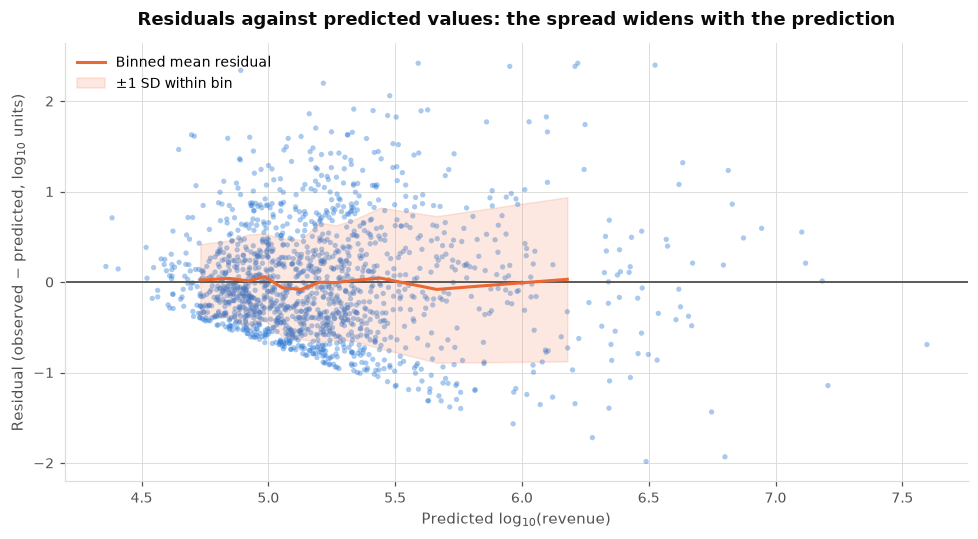

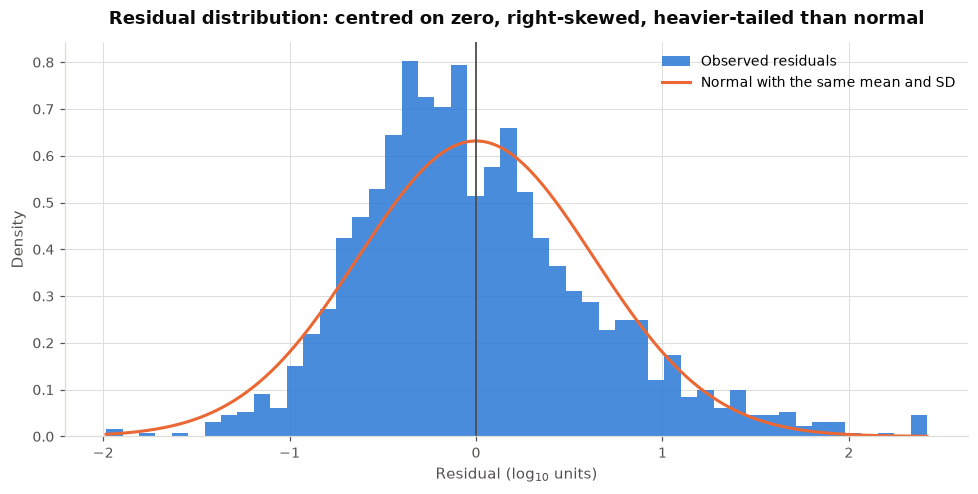

In [10]:
display(plot_residuals_vs_predicted(errors))
display(plot_residual_distribution(errors["residual"]))

In [11]:
from scipy.stats import jarque_bera, spearmanr, ttest_1samp

centring_test = ttest_1samp(errors["residual"], 0)
normality_test = jarque_bera(errors["residual"])
spread_correlation = spearmanr(errors["predicted"], errors["absError"])

print(f"Mean residual              : {errors['residual'].mean():+.6f}")
print(f"Median residual            : {errors['residual'].median():+.4f}")
print(f"t-test that the mean is 0  : t = {centring_test.statistic:+.3f}, p = {centring_test.pvalue:.3f}")
print(f"Jarque-Bera normality test : stat = {normality_test.statistic:.1f}, p = {normality_test.pvalue:.3g}")
print(f"Spearman(predicted, |error|): {spread_correlation.statistic:+.3f}, p = {spread_correlation.pvalue:.3g}")
print()

prediction_quintile = pd.qcut(errors["predicted"], 5, labels=[f"Q{i}" for i in range(1, 6)])
display(
    errors.groupby(prediction_quintile, observed=True)
    .agg(Games=("residual", "size"), **{
        "Mean residual": ("residual", "mean"),
        "SD of residuals": ("residual", "std"),
        "MAE": ("absError", "mean"),
    })
    .round(3)
)

Mean residual              : -0.000587
Median residual            : -0.0878
t-test that the mean is 0  : t = -0.036, p = 0.971
Jarque-Bera normality test : stat = 155.3, p = 1.87e-34
Spearman(predicted, |error|): +0.303, p = 4.02e-33



,Games,Mean residual,SD of residuals,MAE
predicted,,,,
Q1,300,0.026,0.427,0.308
Q2,300,0.017,0.506,0.413
Q3,300,-0.058,0.604,0.501
Q4,300,0.014,0.673,0.555
Q5,300,-0.001,0.859,0.678


**Results and interpretation.** The four questions the assignment poses are
answered in turn.

**Are the residuals centred around zero?** Yes. The mean residual is
$-0.0006$ log units and a one-sample t-test gives $p = 0.971$, so there is no
evidence of overall bias. The median is $-0.088$, and the gap between a mean of
zero and a negative median is the first sign of right skew: most predictions are
slightly too high, and a minority are far too low.

**Do the residuals show systematic patterns?** Not in their *level*. The binned
mean residual in the first figure stays flat along the zero line across the
whole range of predictions, so the model is not systematically over- or
under-predicting in any region of its own output. The systematic behaviour is in
the *spread*, not the centre.

**Is there evidence of heteroscedasticity?** **Yes, and it is unambiguous.**
The Spearman correlation between the prediction and the absolute error is
$+0.303$ with $p \approx 4 \times 10^{-33}$, and the quintile table makes the
size of the effect concrete: the standard deviation of the residuals doubles
from **0.427** in the lowest fifth of predictions to **0.859** in the highest.
MAE rises correspondingly from 0.308 to 0.678.

This violates the constant-variance assumption behind ordinary least squares.
The coefficient estimates remain unbiased, but their standard errors are
understated, so any inference drawn from them would be over-confident. It also
means a single error figure such as MAE describes no part of the data well: it
overstates the error for cheap, low-revenue titles and understates it for the
expensive ones.

**Is there a sector more likely to have high error?** Yes — examined in the
subgroup analysis below.

The residual distribution is centred and unimodal but not normal. Jarque-Bera
returns $p \approx 2 \times 10^{-34}$, and the fitted normal curve sits visibly
below the observed peak and above the shoulders. Skewness is $+0.66$ and excess
kurtosis $+0.85$: a right tail of large under-predictions, and slightly heavier
tails than a normal distribution. Note that this is **after** the log transform;
the same analysis on raw dollars would have been dominated by a handful of games.

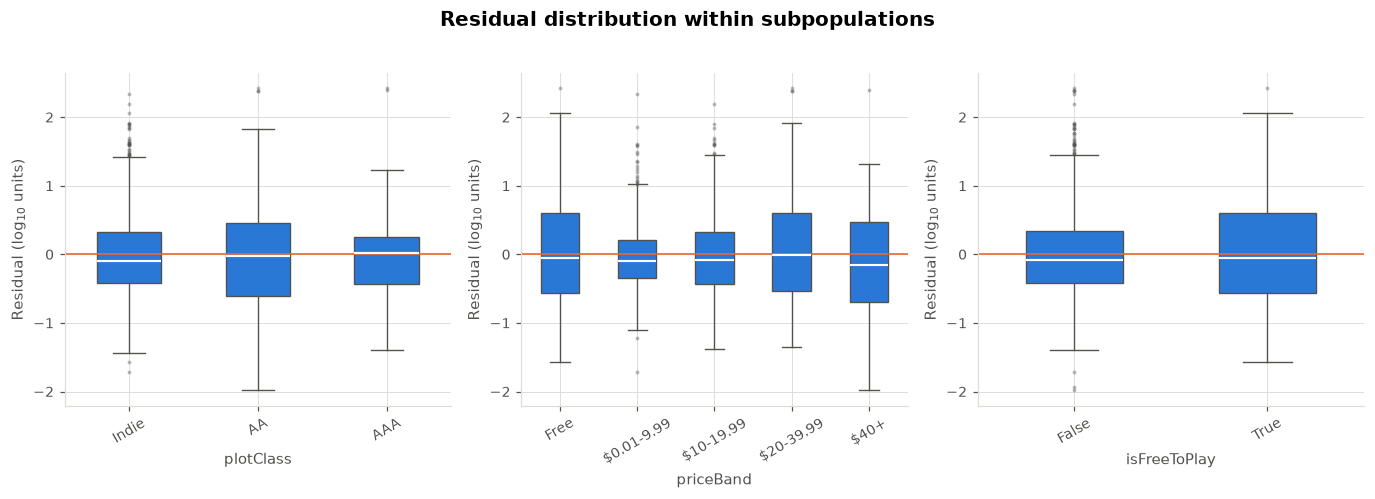

,Variable,Level,Games,Mean residual,SD,MAE
0,plotClass,Indie,1302,-0.001,0.600,0.472
1,plotClass,AA,146,-0.003,0.842,0.654
2,plotClass,AAA,52,0.006,0.728,0.507
3,priceBand,Free,85,-0.006,0.826,0.663
4,priceBand,$0.01-9.99,417,-0.011,0.500,0.376
5,priceBand,$10-19.99,629,-0.015,0.571,0.456
6,priceBand,$20-39.99,304,0.072,0.790,0.642
7,priceBand,$40+,65,-0.118,0.791,0.633
8,isFreeToPlay,False,1415,-0.000,0.618,0.481
9,isFreeToPlay,True,85,-0.006,0.826,0.663


In [12]:
display(plot_error_by_subgroup(errors, ["plotClass", "priceBand", "isFreeToPlay"]))

subgroup_rows = []
for column in ["plotClass", "priceBand", "isFreeToPlay", "selfPublished"]:
    grouped = errors.groupby(column, observed=True)
    for level, group in grouped:
        subgroup_rows.append({
            "Variable": column,
            "Level": str(level),
            "Games": len(group),
            "Mean residual": round(group["residual"].mean(), 3),
            "SD": round(group["residual"].std(), 3),
            "MAE": round(group["absError"].mean(), 3),
        })

errors["reviewScoreMissing"] = errors["reviewScore"].isna()
for level, group in errors.groupby("reviewScoreMissing"):
    subgroup_rows.append({
        "Variable": "reviewScoreMissing",
        "Level": str(level),
        "Games": len(group),
        "Mean residual": round(group["residual"].mean(), 3),
        "SD": round(group["residual"].std(), 3),
        "MAE": round(group["absError"].mean(), 3),
    })

pd.DataFrame(subgroup_rows)

**Which sector carries the highest error?** Three subpopulations stand out, and
the third is the most interesting because it is an artefact of a decision made
in chapter 1.

**Free-to-play titles.** MAE of **0.663** against 0.481 for paid games — roughly
38% worse. The explanation is structural rather than statistical: for these 85
games the listed price is zero and carries no information about how the title
actually monetises. The feature set contains nothing about in-game purchases, so
the model is predicting revenue for a business model it cannot observe.

**Expensive titles.** Error is lowest in the `$0.01–9.99` band (MAE 0.376) and
rises to 0.642 in `$20–39.99` and 0.633 above `$40`. Cheap games occupy a narrow
revenue range and are easy to place; expensive ones span everything from niche
failures to global hits.

**Games whose review score was missing.** This subgroup shows a mean residual of
**+0.300** — the only subpopulation with a clearly biased centre rather than
merely a wider spread. The model **systematically under-predicts these 99 games
by a factor of two**.

The mechanism is traceable. The pipeline imputes the median review score for
these rows, which implicitly treats them as typical. Assignment 1 established
that they are not: games with no review score had a *median revenue of $267,621
against $101,261* for scored games. Median imputation therefore assigns an
average-looking value to a group that is systematically above average, and the
model under-predicts them as a direct consequence.

This is a self-inflicted error, and naming it as such matters: it is not a
property of the data but of the imputation strategy chosen in section 1.5. A
missingness indicator would let the model learn that an absent review score is
itself informative. That is a concrete improvement, carried to chapter 5.

### 2.2 Error as a Function of Features

**Method.** Each numeric feature is plotted against the signed residual and
against the absolute error. The signed plots reveal regions where the model is
biased; the absolute plots reveal regions where it is merely imprecise. The
overlaid line is the mean within equal-count bins of the feature.

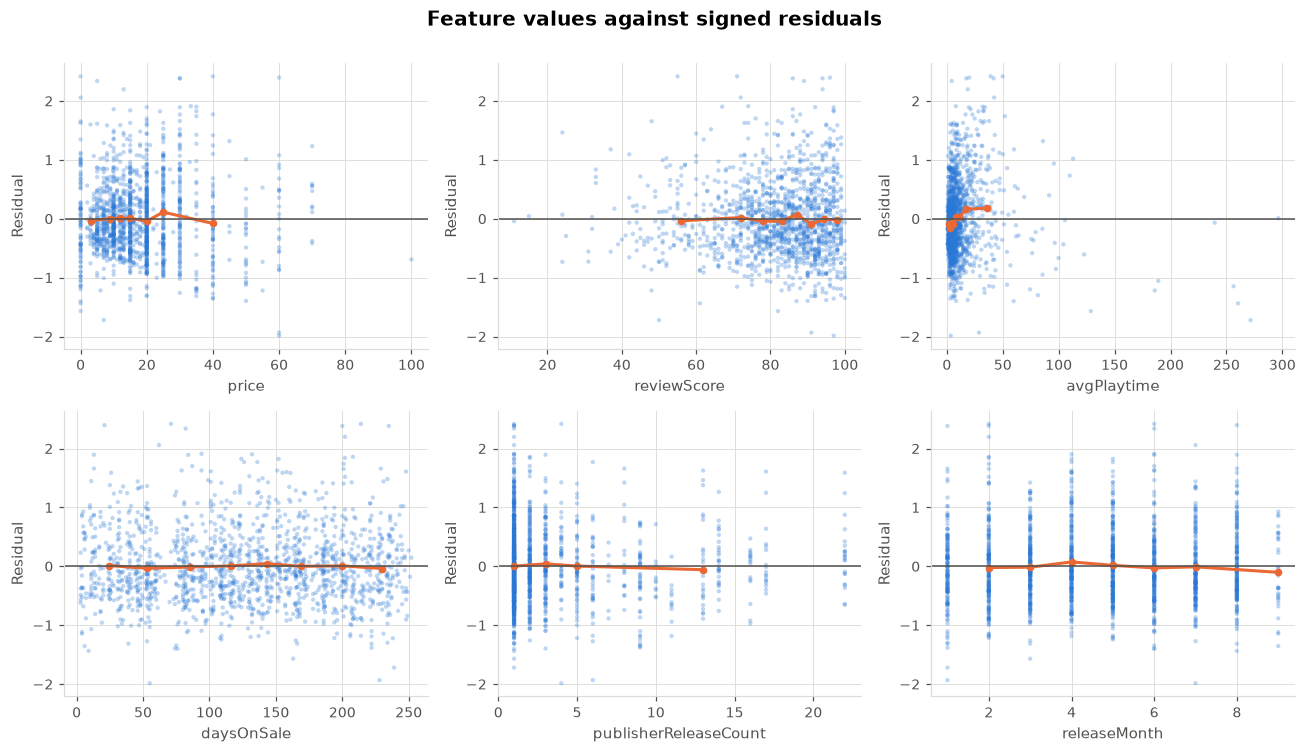

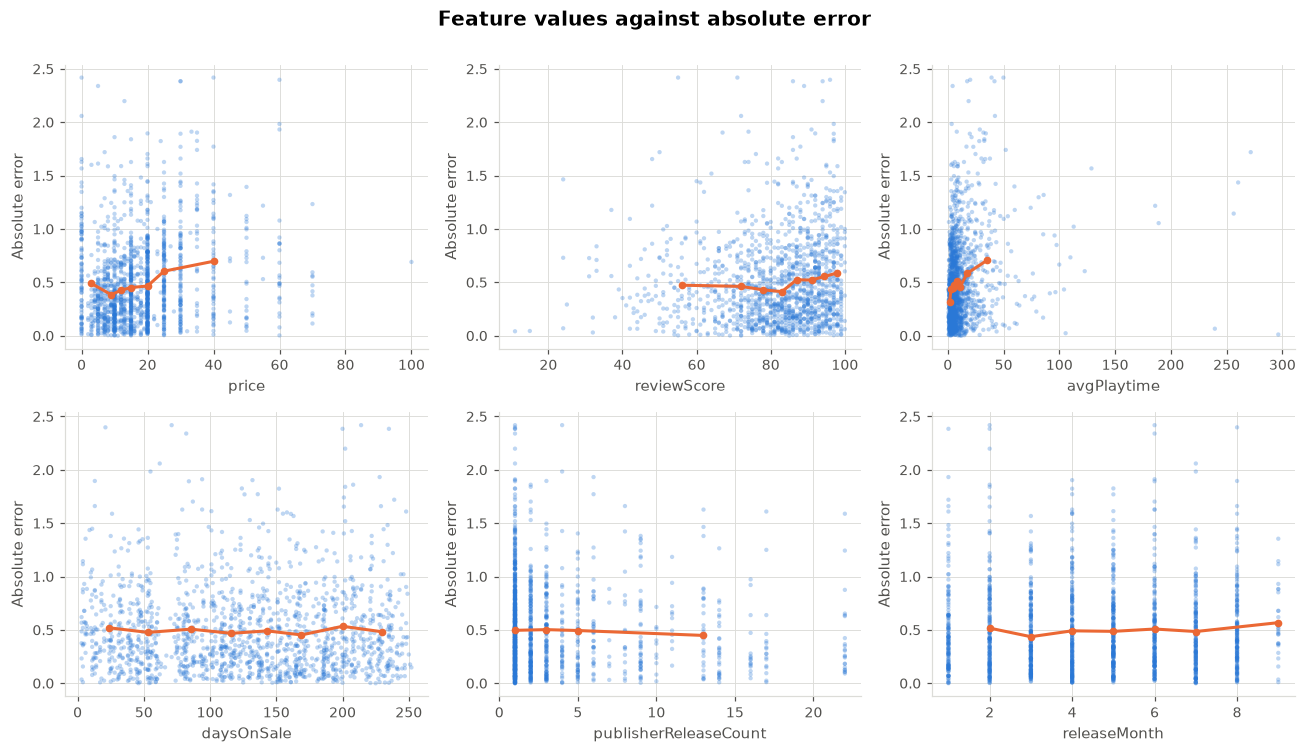

In [13]:
display(plot_feature_error_grid(errors, NUMERIC_FEATURES, "residual",
                                "Feature values against signed residuals"))
display(plot_feature_error_grid(errors, NUMERIC_FEATURES, "absError",
                                "Feature values against absolute error"))

In [14]:
feature_error_rows = []
for feature in NUMERIC_FEATURES:
    subset = errors[[feature, "residual", "absError"]].dropna()
    feature_error_rows.append({
        "Feature": feature,
        "Spearman vs residual": round(spearmanr(subset[feature], subset["residual"]).statistic, 3),
        "Spearman vs |error|": round(spearmanr(subset[feature], subset["absError"]).statistic, 3),
    })
pd.DataFrame(feature_error_rows)

,Feature,Spearman vs residual,Spearman vs |error|
0,price,-0.005,0.176
1,reviewScore,-0.018,0.103
2,avgPlaytime,0.140,0.216
3,daysOnSale,0.008,-0.027
4,publisherReleaseCount,0.023,-0.043
5,releaseMonth,-0.009,0.021


**Results and interpretation.** The signed residuals are close to flat against
every feature — no correlation exceeds $|0.14|$ — which confirms the finding
from 2.1 that the model has no systematic directional bias in feature space.
Against absolute error the picture is different, and it separates the ten
features into two groups.

**Features that predict the size of the error:**

| Feature | ρ vs residual | ρ vs \|error\| |
|---|---|---|
| `avgPlaytime` | +0.140 | **+0.216** |
| `price` | −0.005 | **+0.176** |
| `reviewScore` | −0.018 | +0.103 |

**Features that do not:** `daysOnSale` (−0.027), `publisherReleaseCount`
(−0.043) and `releaseMonth` (+0.021) are all effectively zero.

`avgPlaytime` carries the strongest relationship of the ten, and it is the only
feature with a visible relationship to the *signed* residual as well
($+0.140$): games played for longer tend to be under-predicted, and to be
predicted less accurately. A plausible reading is that high playtime marks
live-service and open-ended titles whose commercial performance depends on
retention mechanics the feature set does not capture — but the data here
supports the association, not the mechanism, and distinguishing them would
require genre and monetisation data.

The flatness of `daysOnSale` is worth noting because it is a *negative* result
with a known cause. Assignment 1 found that revenue does not vary with exposure
in this sample, because selecting the top 1,500 earners removes the relationship
between how long a game has been on sale and how much it earned. The model
inherits that: exposure predicts neither the revenue nor the error.

**Conclusion.** Error concentrates where the price is high and playtime is long,
and is unrelated to when a game was released or how prolific its publisher is.

### 2.3 Analysis of Extreme Errors

**Method.** The largest 5% of absolute errors — 75 games — are isolated and
examined both as a group and individually, and each is attributed to one of the
three causes the assignment names: data quality, model limitation, or a rare
case.

Threshold          : |residual| >= 1.265 log units (a factor of 18.4 in dollars)
Games identified   : 75
Share of total absolute error: 16.5%
Direction          : 60 under-predicted, 15 over-predicted


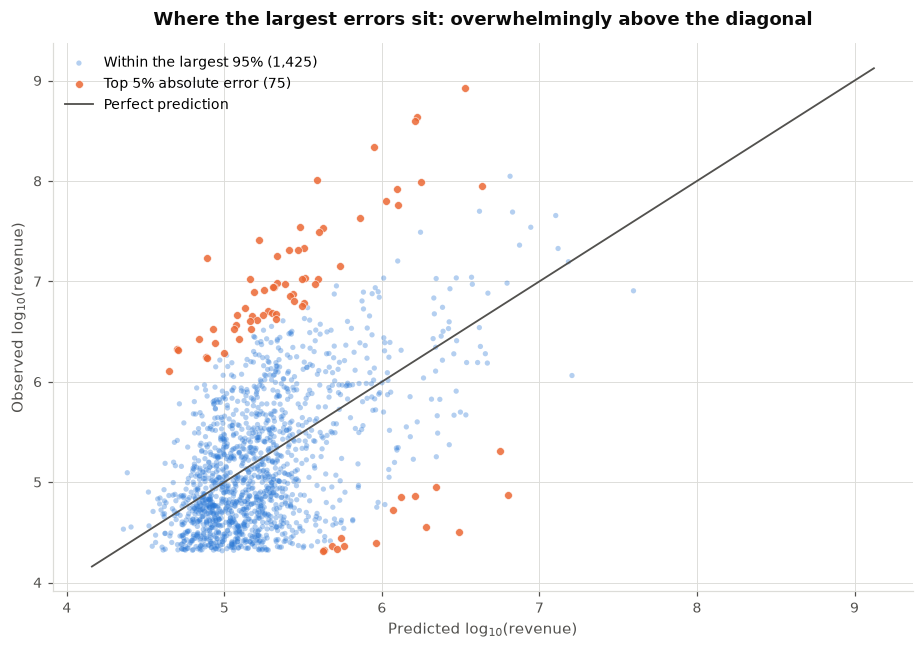

In [15]:
extreme_threshold = errors["absError"].quantile(0.95)
extreme_errors = errors[errors["absError"] >= extreme_threshold]

print(f"Threshold          : |residual| >= {extreme_threshold:.3f} log units "
      f"(a factor of {10 ** extreme_threshold:.1f} in dollars)")
print(f"Games identified   : {len(extreme_errors)}")
print(f"Share of total absolute error: {extreme_errors['absError'].sum() / errors['absError'].sum():.1%}")
print(f"Direction          : {(extreme_errors['residual'] > 0).sum()} under-predicted, "
      f"{(extreme_errors['residual'] < 0).sum()} over-predicted")

display(plot_extreme_errors(errors, extreme_threshold))

In [16]:
comparison = pd.DataFrame({
    "Top 5% by error": [
        extreme_errors["plotClass"].eq("Indie").mean(),
        extreme_errors["isFreeToPlay"].mean(),
        extreme_errors["reviewScore"].isna().mean(),
        extreme_errors["price"].median(),
        extreme_errors["avgPlaytime"].median(),
        extreme_errors["revenue"].median(),
    ],
    "All games": [
        errors["plotClass"].eq("Indie").mean(),
        errors["isFreeToPlay"].mean(),
        errors["reviewScore"].isna().mean(),
        errors["price"].median(),
        errors["avgPlaytime"].median(),
        errors["revenue"].median(),
    ],
}, index=["Indie share", "Free-to-play share", "Review score missing share",
          "Median price (USD)", "Median playtime (hours)", "Median revenue (USD)"])
display(comparison.round(3))

largest = extreme_errors.nlargest(10, "absError")[
    ["name", "revenue", "predicted", "residual", "price", "reviewScore", "avgPlaytime", "plotClass"]
].copy()
largest["predicted revenue (USD)"] = (10 ** largest["predicted"]).round(0)
largest[["name", "revenue", "predicted revenue (USD)", "residual", "price",
         "reviewScore", "avgPlaytime", "plotClass"]]

,Top 5% by error,All games
Indie share,0.707,0.868
Free-to-play share,0.107,0.057
Review score missing share,0.107,0.066
Median price (USD),19.990,14.990
Median playtime (hours),16.869,6.763
Median revenue (USD),5478333.000,109053.000


,name,revenue,predicted revenue (USD),residual,price,reviewScore,avgPlaytime,plotClass
1451,HELLDIVERS™ 2,435635596.0,1660249.0,2.418950,39.99,71.0,39.205960,AAA
1455,The First Descendant,102244808.0,389948.0,2.418635,0.00,55.0,49.870230,AA
1450,Black Myth: Wukong,837793356.0,3349118.0,2.398206,59.99,96.0,20.065041,AAA
1453,Sons Of The Forest,217017892.0,895292.0,2.384531,29.99,86.0,17.341205,AA
1452,Palworld,392328553.0,1619090.0,2.384379,29.99,94.0,41.840761,AA
1477,Chained Together,17039291.0,77863.0,2.340118,4.99,89.0,4.298189,Indie
1470,Supermarket Simulator,26020639.0,164755.0,2.198480,12.99,94.0,18.640685,Indie
1466,Once Human,34530561.0,301095.0,2.059500,0.00,72.0,42.261045,Indie
885,Demon Slayer -Kimetsu no Yaiba- Sweep the Board!,32016.0,3087107.0,-1.984185,59.99,97.0,3.453795,AA
433,Combat Mission: Final Blitzkrieg,73845.0,6319497.0,-1.932361,59.99,91.0,28.695101,AA


**Results.** The threshold falls at 1.265 log units, meaning every game in this
group is mispriced by a **factor of at least 18**. Together these 75 games carry
**16.5% of all absolute error** in the dataset.

The direction is strongly asymmetric: **60 are under-predicted and only 15 are
over-predicted.** The scatter shows this directly — the marked points sit
overwhelmingly above the diagonal.

The group differs from the dataset on every dimension measured. Its median
revenue is **$5.48 million against $109,053** overall — a factor of 50. It is
less Indie (70.7% against 86.8%), more free-to-play (10.7% against 5.7%), more
often missing a review score (10.7% against 6.6%), more expensive ($19.99 against
$14.99) and much longer played (16.9 hours against 6.8).

**Interpretation — attributing the causes.** The three categories the assignment
names apply to identifiably different parts of this group.

**Model limitation — the dominant cause, covering the 60 under-predictions.**
The largest errors are the year's biggest hits: *HELLDIVERS 2* earned $436M
against a prediction of $1.66M, *Black Myth: Wukong* $838M against $3.35M. These
are not strange observations; they are the most important games of 2024, and the
model places them two and a half orders of magnitude too low.

Two mechanisms combine. The first is structural: a linear model predicts near
the centre of the training distribution, and with a median revenue of $109,053
no additive combination of price, playtime and studio class can reach $838M. The
second is informational: the features contain nothing about marketing spend,
franchise recognition, wishlist counts or word-of-mouth — the factors that
actually separate a hit from a competent release. **The model is not wrong about
these games so much as blind to them.**

**Rare and exceptional cases — the 15 over-predictions.** These are more
interesting, because they are failures in the opposite direction. *Demon Slayer:
Sweep the Board!* earned **$32,016** against a prediction of $3.09M, and *Combat
Mission: Final Blitzkrieg* earned **$73,845** against $6.32M. Both are priced at
$59.99, both review well (97 and 91), and both are AA titles. The model sees an
expensive, well-reviewed release from an established studio and predicts
accordingly. These are plausibly niche or licensed products with a small
addressable audience — but the dataset cannot confirm that, and genre or
regional data would be needed to test it. They are labelled rare cases because
they are genuinely atypical, not because the model is misapplied.

**Data quality — a contributing factor, not a primary one.** Free-to-play games
and games with missing review scores are both roughly twice as frequent in this
group as in the dataset. For the free-to-play titles the issue is a genuine gap
in the data: revenue arrives through a channel the features do not describe. For
the missing review scores the issue is the imputation choice identified in 2.1.
Neither explains the blockbusters, which have complete data.

**Conclusion.** The extreme errors are not corrupted records to be cleaned away.
They are the commercially most significant games in the dataset, and the model
fails on them because the features do not contain what makes a hit a hit. This
is a limitation of the problem formulation as much as of the model, and no
change of algorithm will fully repair it — a point tested directly in chapter 3.

### 2.4 Statistical Properties of Errors

**Method.** The assignment asks for the mean absolute error, the standard
deviation of the residuals, and their skewness and kurtosis, with the
interpretation that heavy tails may indicate instability and skew may indicate
systematic bias.

In [17]:
display(residual_statistics(errors["residual"]))

print(f"Median absolute error as a dollar factor : "
      f"x{10 ** errors['absError'].median():.2f}")
print(f"90th percentile of absolute error        : "
      f"x{10 ** errors['absError'].quantile(0.90):.1f}")

,Value
Count,1500.0000
Mean residual,-0.0006
Median residual,-0.0878
MAE,0.4910
Standard deviation,0.6315
Skewness,0.6643
Excess kurtosis,0.8485


Median absolute error as a dollar factor : x2.49
90th percentile of absolute error        : x10.0


**Results and interpretation.**

| Statistic | Value | What it says |
|---|---|---|
| MAE | 0.491 | The typical prediction is out by about half a log unit |
| Standard deviation | 0.632 | Wider than the MAE, reflecting the tail |
| Skewness | +0.664 | Moderate right skew |
| Excess kurtosis | +0.848 | Mildly heavy tails |
| Mean residual | −0.0006 | No overall bias |

**On the MAE.** Half a log unit is best understood back on the dollar scale: the
median absolute error corresponds to a factor of **2.5**, and the 90th percentile
to a factor of **10**. A typical prediction from this model is wrong by a
factor of two and a half, and one prediction in ten is wrong by nearly a factor
of ten. That is the honest summary of its accuracy.

**On the skewness.** The assignment notes that skew may indicate systematic
bias. Here it does *not*, and the distinction matters. The mean residual is zero
to four decimal places and the t-test is emphatically non-significant, so there
is no bias in the usual sense. The $+0.664$ skew instead reflects an **asymmetry
in the shape of the failures**: the model's mistakes are not symmetric because
the phenomenon is not. A game can earn a hundred times more than expected —
*Black Myth: Wukong* did — but it cannot earn a hundred times less than a
prediction that already sits near the bottom of the observed range. The floor
is hard and the ceiling is not.

**On the kurtosis.** An excess kurtosis of $+0.85$ is mild. For comparison, the
model in section 1.3 that included `copiesSold` produced a kurtosis of 27.7, and
the raw revenue variable in Assignment 1 had a skew of 22.9. The transform and
the feature choice together have produced an error distribution that is only
slightly heavier-tailed than normal, which is a considerably better-behaved
starting point for the model comparison than the raw scale would have given.

The practical implication is that **the errors are stable enough for the mean to
be a meaningful summary**, but not so well behaved that it is the only summary
worth reporting. Chapter 3 therefore reports MAE alongside RMSE, which weights
the tail more heavily, and the two will diverge where a model handles the
extremes differently.

**Conclusion.** The residuals are unbiased, moderately right-skewed and mildly
heavy-tailed. The skew is a property of the phenomenon rather than a defect of
the model, and the mild kurtosis confirms that the log transform chosen in
section 0.3 did the work it was intended to do.

## 3. Regression Models

**Method.** The assignment requires three families of model: a linear baseline,
a decision tree, and at least one ensemble. All are trained on the **identical
feature set** defined in section 1.2 and evaluated under the **identical 5-fold
protocol** from section 1.4, so any difference between them is attributable to
the model rather than to its inputs or its resampling.

A fourth entry — an unbounded decision tree — is carried through the comparison
deliberately. It is not a candidate model. It is the evidence for the
bias–variance argument in section 3.5, and it shows what the depth constraint in
3.2 is protecting against.

In [18]:
from error_analysis.plots import (
    plot_explanation_comparison,
    plot_fold_stability,
    plot_metric_comparison,
    plot_predicted_vs_actual,
    plot_tree_depth_curve,
)
from error_analysis.regression_models import (
    TREE_MAX_DEPTH,
    compare_explanations,
    describe_hyperparameters,
    measure_noise_sensitivity,
    run_model_comparison,
    sweep_tree_depth,
)

describe_hyperparameters()

,scikit-learn class,Configuration
Model,,
Linear Regression,LinearRegression,"All defaults. Ordinary least squares, no regul..."
Decision Tree (unbounded),DecisionTreeRegressor,"All defaults, so the depth is unlimited. Retai..."
Decision Tree (max_depth=3),DecisionTreeRegressor,"max_depth=3, chosen by the sweep in 3.2. Other..."
Random Forest,RandomForestRegressor,"n_estimators=300, min_samples_leaf=2. Other se..."


### 3.1 Linear Regression

**Method.** Ordinary least squares on the standardised numeric features and
one-hot encoded categoricals, with no regularisation. This is the model whose
errors chapter 2 analysed; its results are restated here so the comparison is
self-contained.

**Results.** Out-of-fold R² = 0.286, MAE = 0.491 log units, a median error
factor of 2.49.

**Interpretation.** The model is unbiased and its residuals are well behaved,
but it explains under a third of the variance in log revenue. Chapter 2 traced
this to two causes: heteroscedasticity that violates its constant-variance
assumption, and a feature set that contains nothing about the marketing,
franchise or word-of-mouth factors that separate a hit from a competent release.

Its value here is as a reference point. Any more flexible model must beat 0.286
to justify the loss of interpretability that comes with it.

### 3.2 Decision Tree Regressor

**Method.** A single regression tree partitions the feature space into regions
and predicts the mean of each. Because an unconstrained tree on 1,500 rows can
place almost every observation in its own leaf, `max_depth` is swept rather than
assumed, and both the training and out-of-fold scores are recorded at each depth.

,Train R2,Test R2,Gap
max_depth,,,
2,0.291,0.249,0.042
3,0.339,0.275,0.063
4,0.391,0.256,0.134
5,0.450,0.245,0.205
6,0.510,0.201,0.309
8,0.632,0.076,0.556
10,0.746,-0.043,0.789
15,0.949,-0.220,1.169
unbounded,1.000,-0.235,1.235


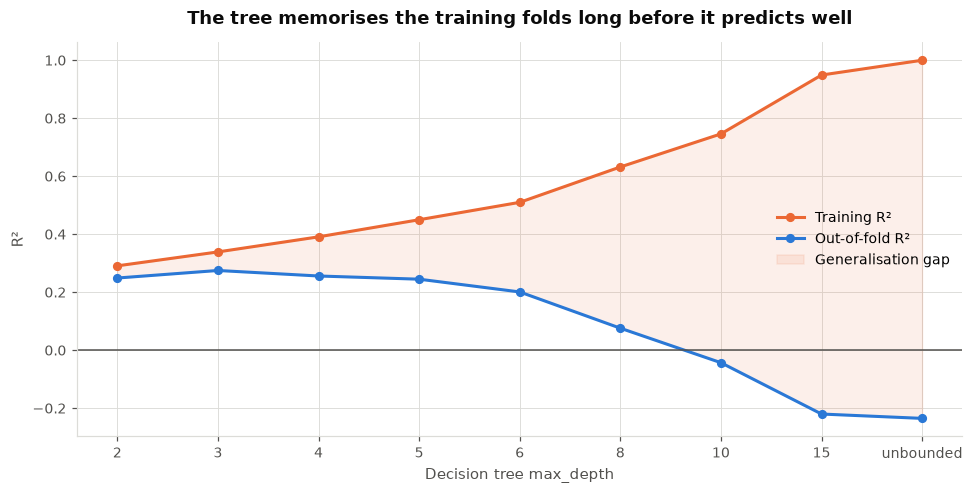

In [19]:
depth_sweep = sweep_tree_depth(games[ALL_FEATURES], games[REGRESSION_TARGET], REGRESSION_CV)
display(depth_sweep)
display(plot_tree_depth_curve(depth_sweep))

**Results.** The sweep is an unusually clean demonstration of overfitting.

| max_depth | Train R² | Out-of-fold R² | Gap |
|---|---|---|---|
| 2 | 0.291 | 0.249 | 0.042 |
| **3** | 0.339 | **0.275** | 0.063 |
| 5 | 0.450 | 0.245 | 0.205 |
| 10 | 0.746 | −0.043 | 0.789 |
| unbounded | **1.000** | **−0.235** | **1.235** |

**Interpretation.** The unbounded tree achieves a training R² of exactly 1.000 —
it reproduces every training value perfectly — and an out-of-fold R² of −0.235.
A negative R² means the model performs **worse than predicting the mean revenue
for every game**. It has memorised the training folds and learned nothing that
transfers.

The behaviour in between is the bias–variance trade-off made visible. Training
score rises monotonically with depth because a deeper tree can always fit the
training data more closely. Out-of-fold score peaks at **depth 3** and then falls
away, crossing zero between depths 8 and 10. The gap between the two curves —
the shaded region — is variance, and it grows without limit.

**Conclusion.** `max_depth=3` is carried forward. At that setting the tree scores
0.275, which is marginally *below* the linear model's 0.286. **A single tree,
properly constrained, buys nothing over a linear model on this data** — and
properly unconstrained it is actively harmful.

### 3.3 Random Forest Regressor

**Method.** The ensemble required by the assignment. 300 trees, each grown on a
bootstrap sample with a random subset of features considered at each split, with
`min_samples_leaf=2` as a mild constraint. Averaging over many decorrelated trees
is intended to keep the flexibility that made a single deep tree overfit while
cancelling out the variance that came with it.

### 3.4 Model Comparison

**Method.** All four models scored on the same folds, on multiple metrics, with
the per-fold spread reported alongside the means so that the differences can be
judged against the noise in the estimates.

,MAE,MSE,RMSE,R2,Median error factor,Train R2,Overfit gap,R2 SD across folds,Fit time (s)
Model,,,,,,,,,
Linear Regression,0.4910,0.3985,0.6313,0.2855,2.49,0.305,0.024,0.052,0.03
Decision Tree (unbounded),0.6328,0.6897,0.8305,-0.2366,3.07,1.000,1.235,0.034,0.04
Decision Tree (max_depth=3),0.4963,0.4026,0.6345,0.2781,2.52,0.339,0.063,0.040,0.03
Random Forest,0.4704,0.3628,0.6023,0.3495,2.46,0.847,0.500,0.046,0.97


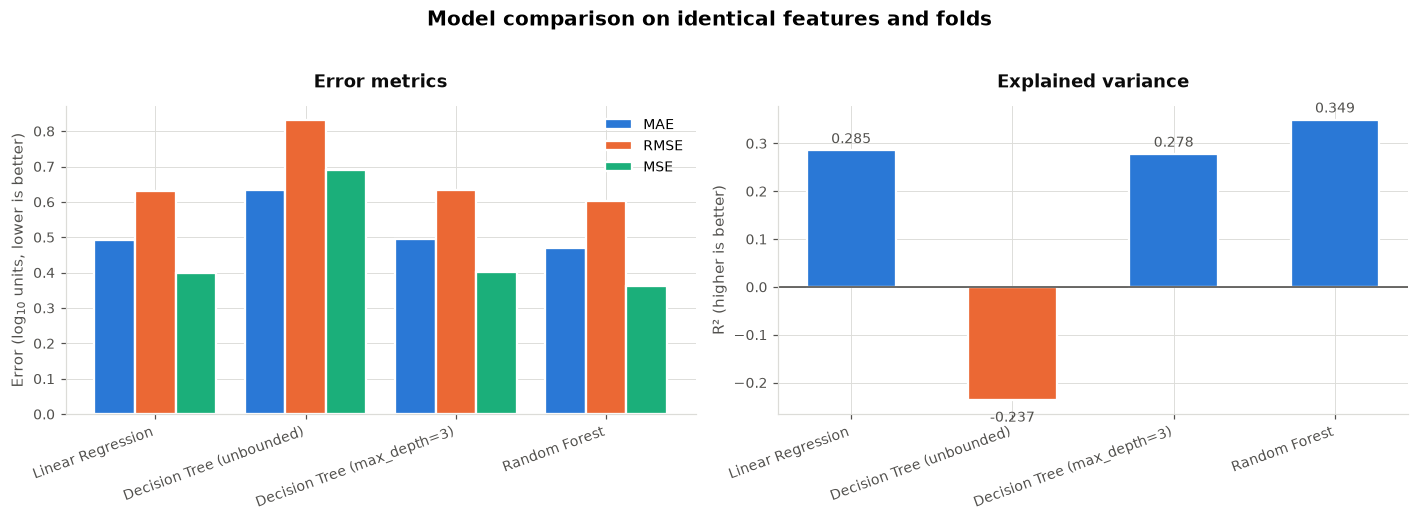

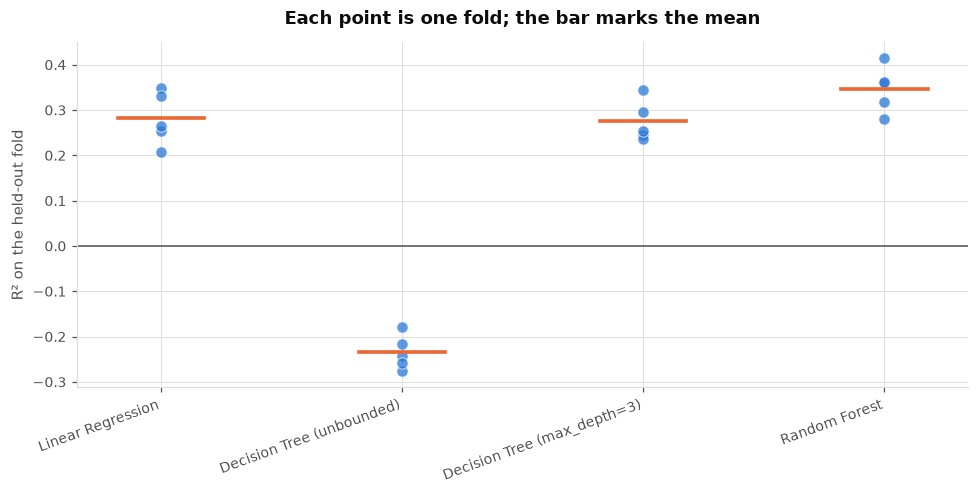

In [20]:
metrics_table, model_predictions, fold_scores = run_model_comparison(
    games[ALL_FEATURES], games[REGRESSION_TARGET], REGRESSION_CV
)
display(metrics_table)
display(plot_metric_comparison(metrics_table))
display(plot_fold_stability(fold_scores))

**Results.**

| Model | MAE | MSE | RMSE | R² | Error factor | Train R² | Overfit gap | R² SD/fold |
|---|---|---|---|---|---|---|---|---|
| Linear Regression | 0.491 | 0.399 | 0.631 | 0.286 | ×2.49 | 0.305 | 0.024 | 0.052 |
| Decision Tree (unbounded) | 0.633 | 0.690 | 0.831 | −0.237 | ×3.07 | 1.000 | 1.235 | 0.034 |
| Decision Tree (depth 3) | 0.496 | 0.403 | 0.635 | 0.278 | ×2.52 | 0.339 | 0.063 | 0.040 |
| **Random Forest** | **0.470** | **0.363** | **0.602** | **0.350** | **×2.46** | 0.847 | 0.500 | 0.046 |

**Interpretation.** The Random Forest wins on **every metric simultaneously**,
which removes the usual difficulty of trading one against another. Its R² of
0.350 is 0.064 above the linear model, its MAE is 4% lower, and its RMSE is 5%
lower.

That RMSE improves slightly more than MAE is informative. RMSE penalises large
errors more heavily, so the forest is gaining a little more on the tail than in
the middle of the distribution — it handles the hard cases marginally better,
though section 3.5 shows how marginal that is.

**The improvement is real but should not be overstated.** The fold-level scatter
shows why: the per-fold standard deviation is roughly 0.05, and the gap between
the forest and the linear model is 0.064. The advantage is about the size of one
standard deviation of fold-to-fold noise, and the two models' fold scores
overlap. The forest is better, but this is not a decisive separation, and a
different random seed would narrow or widen it.

The overfit gap column carries a warning about the forest that the headline
metrics conceal. Its training R² is 0.847 against an out-of-fold 0.350, a gap of
0.500. It is fitting a great deal of structure that does not generalise. That it
still outperforms is a credit to the averaging, but it is not a model operating
comfortably within its capacity.

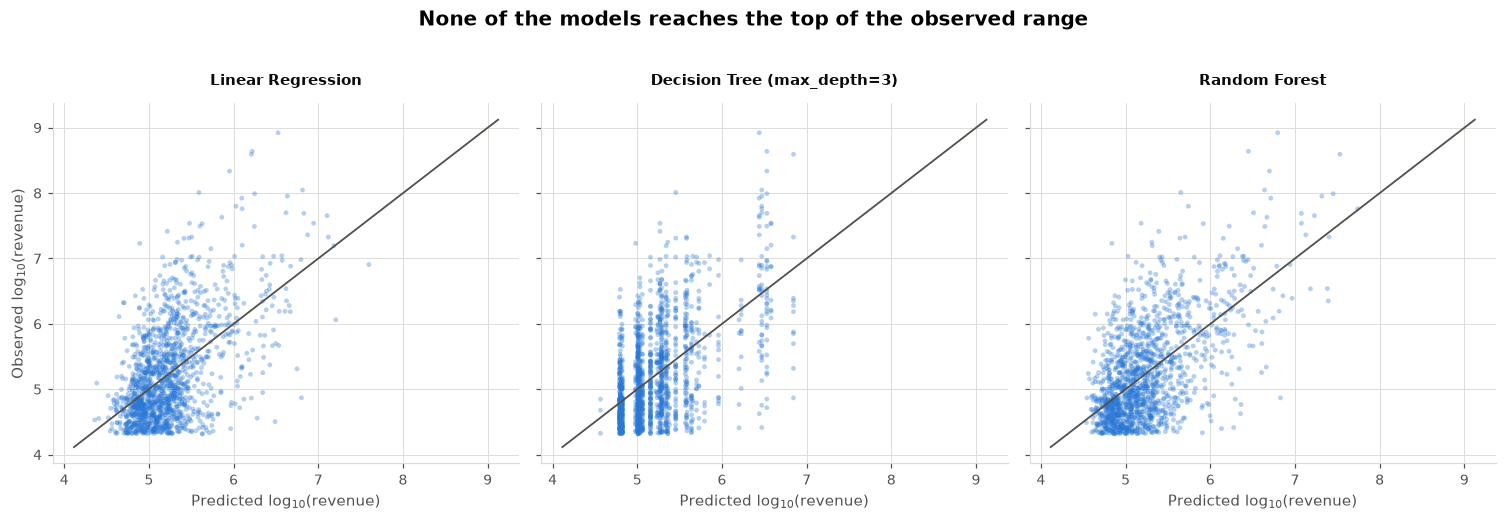

,"MAE, all games","MAE, hardest 75"
Model,,
Linear Regression,0.491,1.616
Decision Tree (unbounded),0.633,1.144
Decision Tree (max_depth=3),0.496,1.329
Random Forest,0.470,1.277


name,Black Myth: Wukong,HELLDIVERS™ 2,Palworld,Sons Of The Forest,Dragon's Dogma 2
Actual revenue,837793356.0,435635596.0,392328553.0,217017892.0,111478291.0
Linear Regression,3349118.0,1660249.0,1619090.0,895292.0,6511496.0
Decision Tree (unbounded),89781931.0,312155.0,57595515.0,392328553.0,3465018.0
Decision Tree (max_depth=3),2755628.0,3388524.0,6988459.0,3388524.0,2952141.0
Random Forest,6249606.0,2821429.0,33857563.0,4994907.0,4375326.0


In [21]:
display(plot_predicted_vs_actual(
    model_predictions,
    games[REGRESSION_TARGET],
    ["Linear Regression", f"Decision Tree (max_depth={TREE_MAX_DEPTH})", "Random Forest"],
))

hardest = errors["absError"] >= errors["absError"].quantile(0.95)
hard_case_rows = []
for name, predicted in model_predictions.items():
    model_residual = games[REGRESSION_TARGET] - predicted
    hard_case_rows.append({
        "Model": name,
        "MAE, all games": round(model_residual.abs().mean(), 3),
        "MAE, hardest 75": round(model_residual[hardest].abs().mean(), 3),
    })
display(pd.DataFrame(hard_case_rows).set_index("Model"))

biggest_hits = games.nlargest(5, "revenue")
hit_predictions = {"Actual revenue": biggest_hits["revenue"].round(0).to_numpy()}
for name, predicted in model_predictions.items():
    hit_predictions[name] = (10 ** pd.Series(predicted, index=games.index)[biggest_hits.index]).round(0).to_numpy()
pd.DataFrame(hit_predictions, index=biggest_hits["name"]).T

**Where all the models still fail.** The predicted-against-observed panels are
nearly identical in one respect: none of the three reaches the top of the
observed range. Every model's predictions compress into a band far narrower than
the data.

Restricting attention to the 75 games chapter 2 identified as hardest makes this
concrete. The linear model's MAE on them is 1.616; the forest reduces it to
1.277 — a 21% improvement, and still an error of more than a factor of eighteen.

The five biggest hits show the same story in dollars. *Black Myth: Wukong* earned
$838M. The linear model predicts $3.3M and the forest $6.2M. The forest nearly
doubles the prediction and remains **135 times too low**.

**This is the most important negative result in the chapter.** Moving from a
linear model to an ensemble does not fix the failure identified in chapter 2. It
cannot, because the failure is not caused by the functional form. No model can
recover information the features do not contain, and nothing in this feature set
distinguishes a game that will sell fifteen million copies from one that will
sell fifty thousand.

### 3.5 Critical Discussion

The assignment asks the discussion to address eight specific aspects. Each is
taken in turn.

**Relative performance across metrics.** The ranking is consistent: Random
Forest, then Linear Regression, then the depth-3 tree, then the unbounded tree.
Unusually, no metric disagrees — MAE, MSE, RMSE and R² all order the models
identically, so there is no trade-off to adjudicate. The differences among the
top three are small: 0.026 log units of MAE separates the best from the third.

**Whether the model assumptions hold.** For the linear model they largely do not.
Chapter 2.1 established clear heteroscedasticity, with the residual standard
deviation doubling across the range of predictions, which violates the constant
variance assumption directly. Normality is rejected at $p \approx 10^{-34}$.
Linearity is questionable: `avgPlaytime` shows a curved relationship with the
target. Independence is the one assumption that plausibly holds, since the games
are separate titles — though publishers with several releases introduce a mild
dependence that this analysis does not model. The tree-based models make none of
these assumptions, which is a large part of why the forest does better.

**Bias–variance.** The depth sweep in 3.2 measures this rather than describing
it. The linear model is the high-bias, low-variance end: a training R² of 0.305
against an out-of-fold 0.286, a gap of 0.024, meaning it barely overfits at all
and is limited by its own rigidity. The unbounded tree is the opposite extreme, a
gap of 1.235. The forest sits between at 0.500 — considerable variance, but
averaged across 300 trees rather than concentrated in one.

**Sensitivity to outliers and noise.** Tested directly below rather than
asserted.

In [22]:
display(measure_noise_sensitivity(games[ALL_FEATURES], games[REGRESSION_TARGET], REGRESSION_CV))

,Linear Regression,Decision Tree (max_depth=3),Random Forest
Noise SD (log units),,,
0.00,0.282,0.275,0.347
0.25,0.244,0.230,0.287
0.50,0.206,0.191,0.210


Adding Gaussian noise to the target erodes the forest's advantage. At zero added
noise it leads the linear model by 0.065 R²; at a noise SD of 0.25 log units the
lead narrows to 0.043; at 0.5 it is 0.004 — effectively gone. The extra structure
the forest finds is real but fragile, and it is the first thing lost when the
signal degrades. On outliers, chapter 2.3 showed the picture is mixed: the
extreme values dominate the linear fit through squared error, while the forest is
more robust to them in principle but, as 3.4 showed, still cannot predict them.

**Where linear models fail, and why.** Two distinct failures appear here. The
first is *functional*: revenue is generated multiplicatively, and a model additive
in its features cannot represent that. The log transform of the target addresses
much of it, which is precisely why the linear model performs as well as it does.
The second is *distributional*: least squares minimises squared error under an
assumption of constant variance that section 2.1 disproved, so the fit is pulled
disproportionately by the high-variance, high-prediction region.

**Where tree-based models help.** Non-monotonic relationships are the clearest
case. Assignment 1 found that free-to-play games have the *highest* median
playtime of any price band, breaking an otherwise increasing pattern — a shape a
linear coefficient cannot express but a split can. Trees also capture
interactions without being told to look for them, and require no assumption
about error distribution. The forest's 0.064 R² advantage is the aggregate of
these gains.

**Interpretability against performance.** The two models explain the data in
genuinely different ways, and the comparison below makes the trade-off concrete.

,Linear coefficient,Random Forest importance
avgPlaytime,0.141,0.383
price,0.271,0.181
reviewScore,0.087,0.117
daysOnSale,0.050,0.116
publisherReleaseCount,-0.036,0.057
plotClass_Indie,-0.408,0.051
releaseMonth,0.014,0.020
selfPublished,-0.040,0.015
releaseWeekday_Thursday,0.068,0.015
releaseWeekday_Tuesday,0.118,0.014


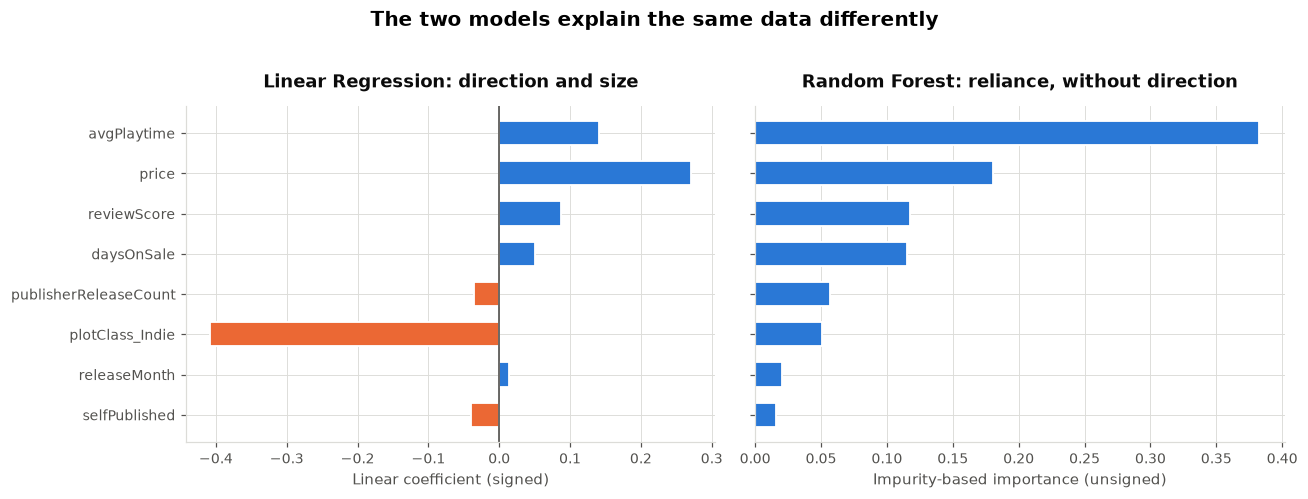

In [23]:
explanations = compare_explanations(games[ALL_FEATURES], games[REGRESSION_TARGET])
display(explanations.round(3).head(10))
display(plot_explanation_comparison(explanations))

The linear model gives signed, directional statements: holding everything else
fixed, a one-standard-deviation increase in price raises predicted log revenue by
0.271, and an Indie release is 0.408 log units — a factor of 2.6 — below an AA
release. Those are falsifiable claims a domain expert can argue with.

The forest gives magnitudes without direction. It ranks `avgPlaytime` first at
0.383 importance, but importance does not say whether more playtime means more
revenue, or over what range, or whether the effect reverses.

**The two disagree sharply on one feature, and the disagreement is instructive.**
`isFreeToPlay` carries the largest linear coefficient of any feature at 0.566,
yet the forest assigns it an importance of 0.005 — essentially nothing. The
explanation is that the forest can reach the same conclusion through `price`,
since `price = 0` is exactly what defines the flag, so the split on price
absorbs the information and the redundant indicator is never chosen. The linear
model, which cannot represent a discontinuity at zero, needs the explicit
indicator to do it.

One caveat on reading the coefficients: numeric features are standardised while
the booleans are raw 0/1, so a coefficient of 0.566 on `isFreeToPlay` and 0.271
on `price` are not measured in the same units and their magnitudes are not
directly comparable.

**What was learned from the modelling stage.** Three things, in order of how much
they changed the picture.

First, **the ceiling on this problem is set by the features, not the algorithm.**
Moving from ordinary least squares to a 300-tree ensemble raises R² from 0.286 to
0.350 and leaves the largest errors almost untouched. That bounds how much any
further modelling effort could achieve.

Second, **model complexity is not monotonically useful.** The unbounded tree
achieved a perfect training fit and predicted worse than a constant. Without
out-of-fold evaluation it would have looked like the best model in the
comparison.

Third, **a small advantage measured once is not a reliable advantage.** The
forest's lead is comparable to the fold-to-fold noise and disappears under
modest label noise. Reporting the per-fold spread alongside the mean is what
made that visible.

### 3.6 Preferred Model

**The Random Forest is selected for further analysis**, with the reservations
below stated as part of the choice rather than as an afterthought.

**The case for it.** It leads on all four metrics simultaneously, it makes none
of the distributional assumptions that section 2.1 showed to be violated, it
handles the non-monotonic price–playtime relationship that a linear model cannot
express, and it performs best on the hardest 5% of cases even though it does not
solve them.

**The case against, and why it does not prevail.** Its margin over the linear
model is about one fold-standard-deviation, and it vanishes under added noise. It
overfits substantially, with a training-to-test gap of 0.500. It is roughly 25
times slower to fit, which is irrelevant at 1,500 rows and would not be at a
million. Most importantly, it sacrifices the directional interpretability that
makes the linear model useful for explanation rather than prediction.

**The deciding consideration** is the purpose set out in chapter 0: this notebook
exists to analyse errors, and the forest produces the smallest and best-behaved
error distribution while remaining honest about the cases it cannot reach.

**A qualification that matters.** If the objective were explanation rather than
prediction — understanding *which* attributes drive revenue and in which
direction — the linear model would be the better choice despite scoring lower.
Its coefficients are interpretable, its assumptions are testable, and its
failures, as chapter 2 showed, are diagnostic. A 0.064 improvement in R² is a
poor trade for the ability to state what the model believes and why.

**Conclusion.** The Random Forest is preferred for prediction on this data, by a
margin that is real but narrow. Neither model addresses the fundamental
limitation: the features do not contain what makes a game a commercial hit.

## 4. Classification Error Analysis

**Method.** The task is to predict whether a game is a **commercial standout**,
defined in section 0.3 as revenue at or above the 75th percentile — $455,157.
That gives 375 positives against 1,125 negatives.

Two classifiers are used: **Logistic Regression** as a linear baseline and a
**Random Forest Classifier**. The assignment does not require more than one; a
second is included so that section 4.7 has something to compare, and because the
two fail in different ways.

Every probability below comes from `cross_val_predict(method="predict_proba")`
under the stratified 5-fold protocol from section 1.4, so no confusion matrix
entry, threshold or ROC point reflects a model scoring data it was trained on.

In [24]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

from error_analysis.classification_models import (
    BETA_VALUES,
    DEFAULT_THRESHOLD,
    compare_features_by_outcome,
    describe_classifier_hyperparameters,
    confidence_of_prediction,
    error_rate_by_revenue_decile,
    fbeta_grid,
    high_confidence_errors,
    out_of_fold_probabilities,
    summarise_classifiers,
    summarise_confidence,
    threshold_sweep,
)
from error_analysis.plots import (
    plot_confidence_distributions,
    plot_confusion_matrices,
    plot_error_rate_by_decile,
    plot_fbeta_curves,
    plot_feature_outcome_distributions,
    plot_roc_curves,
    plot_threshold_curves,
)

class_target = games[CLASSIFICATION_TARGET]
class_probabilities = out_of_fold_probabilities(games[ALL_FEATURES], class_target, CLASSIFICATION_CV)

display(describe_classifier_hyperparameters())

summarise_classifiers(class_target, class_probabilities)

,scikit-learn class,Configuration
Model,,
Logistic Regression,LogisticRegression,max_iter=2000 so the solver converges. Other s...
Random Forest,RandomForestClassifier,"n_estimators=300, min_samples_leaf=2, matching..."


,TP,FP,FN,TN,Accuracy,Balanced accuracy,Precision,Recall,F1,MCC,ROC-AUC
Model,,,,,,,,,,,
Logistic Regression,120,52,255,1073,0.795,0.637,0.698,0.320,0.439,0.372,0.7782
Random Forest,157,56,218,1069,0.817,0.684,0.737,0.419,0.534,0.458,0.7934


### 4.1 Confusion Matrix Analysis

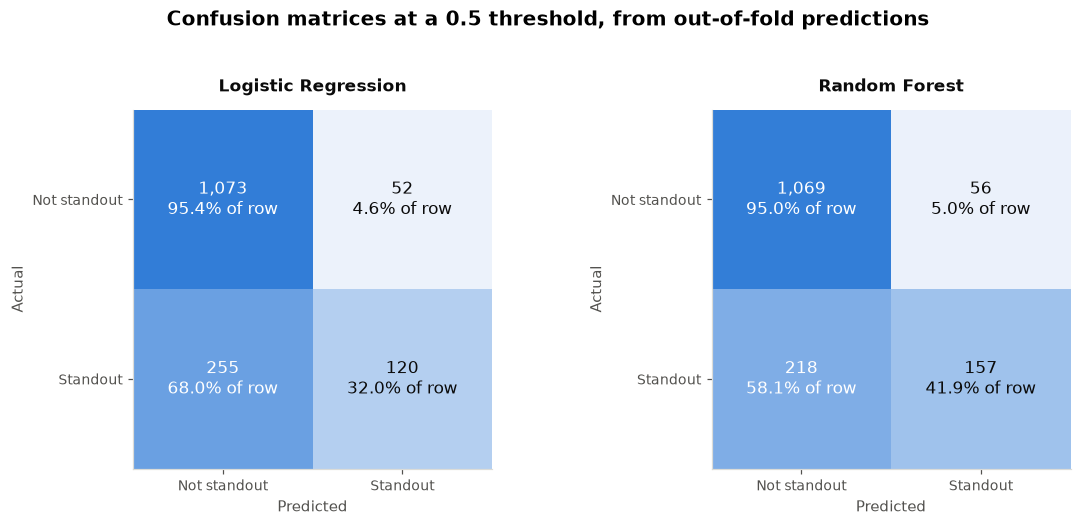

Always predicting 'not a standout' would score 75.0% accuracy.


In [25]:
confusion_matrices = {
    name: confusion_matrix(class_target, (probability >= DEFAULT_THRESHOLD).astype(int), labels=[0, 1])
    for name, probability in class_probabilities.items()
}
display(plot_confusion_matrices(confusion_matrices))

print(f"Always predicting 'not a standout' would score "
      f"{(class_target == 0).mean():.1%} accuracy.")

**Results.** At the default 0.5 threshold:

| Model | TP | FP | FN | TN | Accuracy | Balanced acc. | Precision | Recall | F1 | MCC | ROC-AUC |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Logistic Regression | 120 | 52 | 255 | 1,073 | 0.795 | 0.637 | 0.698 | 0.320 | 0.439 | 0.372 | 0.778 |
| **Random Forest** | 157 | 56 | 218 | 1,069 | 0.817 | 0.684 | 0.737 | **0.419** | **0.534** | **0.458** | **0.793** |

**Interpretation.** The first thing the matrix shows is that **accuracy is the
wrong metric here.** Always predicting "not a standout" scores 75.0%. The Random
Forest scores 81.7% — an improvement of under seven points over a model that
makes no use of the data at all. Balanced accuracy (0.684) and MCC (0.458) are
the honest summaries, and both make clear the model is doing real but limited
work.

The second and more important observation is the **severe asymmetry between the
two error types**. The Random Forest produces 218 false negatives against 56
false positives — nearly four times as many. It identifies only **42% of actual
standouts** while being right 74% of the time when it does predict one.

This is not a defect of the model so much as a rational response to the class
balance. With 75% of games in the negative class, a probability threshold of 0.5
is a high bar: predicting "standout" requires the model to be more than half
certain, and on a minority class with overlapping features it rarely is. Section
4.5 shows what happens when that bar is moved.

The Random Forest beats Logistic Regression on every metric, and by a clearer
margin than in the regression comparison: MCC 0.458 against 0.372, recall 0.419
against 0.320. The non-linear boundary is worth more for this task than it was
for predicting the continuous target.

### 4.2 False Positives and False Negatives

**Which error is more critical here?** The answer follows from the decision the
classifier stands in for. Treating the model as a screening tool for which games
merit commercial attention — investment, marketing, portfolio inclusion — the two
errors have very different consequences:

- A **false positive** backs a title that does not deliver. The cost is bounded
  by the amount committed.
- A **false negative** passes on a genuine standout. The cost is the entire
  upside forgone, and chapter 2 established how large that upside can be. The
  dataset's largest earner made $838M.

**In this framing the false negative is far more expensive, and it is also the
error the model makes four times more often.** The model is mis-tuned relative to
the asymmetry of the problem: it is conservative exactly where conservatism is
most costly. Section 4.5 quantifies the fix and section 4.6 formalises the
trade-off through $F_\beta$.

The opposite framing is worth stating for completeness. If the classifier were
used to *allocate a fixed budget* rather than to screen, a false positive would
consume capital that a true positive could have used, and precision would
matter more. The right threshold is not a property of the model — it is a
property of what the prediction is used for, and this notebook cannot settle it
without knowing that.

**Where does the model fail systematically?** Examined below.

,Games,Actual standouts,Errors,Error rate
decile,,,,
1,150,0,4,0.027
2,150,0,2,0.013
3,150,0,3,0.020
4,150,0,5,0.033
5,150,0,7,0.047
6,150,0,10,0.067
7,150,0,14,0.093
8,150,75,71,0.473
9,150,150,99,0.660


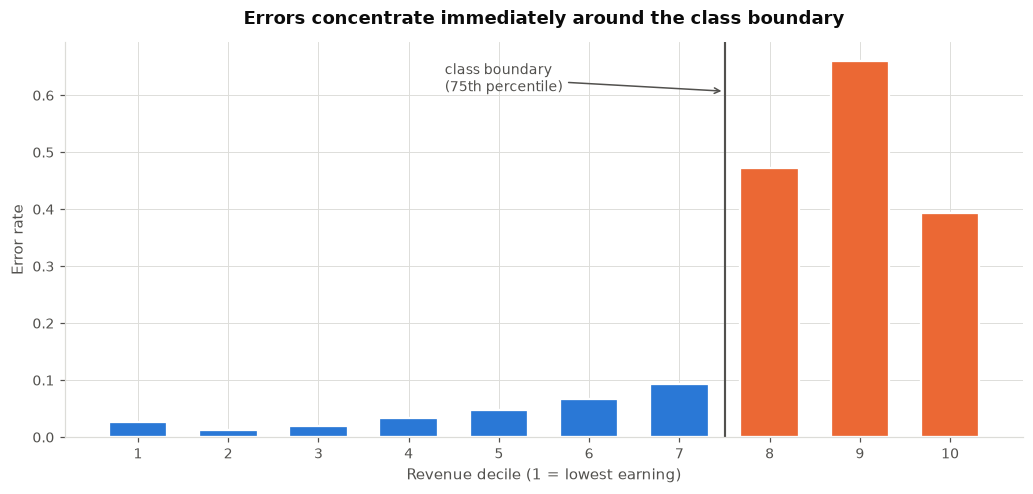

In [26]:
random_forest_probability = class_probabilities["Random Forest"]
predicted_class = (random_forest_probability >= DEFAULT_THRESHOLD).astype(int)
is_correct = pd.Series(predicted_class == class_target, index=games.index)

decile_errors = error_rate_by_revenue_decile(games, class_target, is_correct)
display(decile_errors)
display(plot_error_rate_by_decile(decile_errors, boundary_decile=8))

**Results and interpretation.** Grouping the errors by revenue decile localises
the failure precisely, and the pattern is unambiguous.

| Revenue decile | Error rate |
|---|---|
| 1–7 (all negatives) | 0.013 – 0.093 |
| **8** (straddles the boundary) | **0.473** |
| **9** (just above) | **0.660** |
| 10 (the largest earners) | 0.393 |

The model is almost perfect on the bottom 70% of the revenue distribution and
close to a coin flip immediately above the class boundary. **Decile 9 — games
earning somewhat more than the threshold — is where two out of every three
predictions are wrong.**

This is the systematic failure region, and its location is informative. The
class label is a threshold imposed on a continuous quantity, so games either side
of $455,157 are nearly identical in every respect except which label they
received. The model has no way to separate them because there is very little to
separate. Decile 8 contains 75 standouts and 75 non-standouts, and the model
resolves that split barely better than chance.

Decile 10 recovers to a 0.393 error rate: the very largest earners are
distinguishable again, because their feature profiles are more extreme. But even
there the model misses nearly 40%, which connects directly to chapter 2 — these
are the same blockbusters the regression under-predicted by two orders of
magnitude.

**The conclusion is that the errors are not distributed across the population.
They are concentrated in a narrow band around an artificial cut point,** and any
statement about this model's accuracy should be read as conditional on where in
the revenue distribution a game sits.

### 4.3 Probability-Based Analysis

**Method.** For every game, the model's confidence in whichever class it chose is
$p$ if it predicted the positive class and $1-p$ otherwise. Comparing the
distribution of that confidence for correct and incorrect predictions shows
whether the model knows when it is likely to be wrong.

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
Correct,1226.0,0.815,0.121,0.502,0.733,0.844,0.912,0.999
Incorrect,274.0,0.722,0.133,0.501,0.615,0.721,0.833,0.989


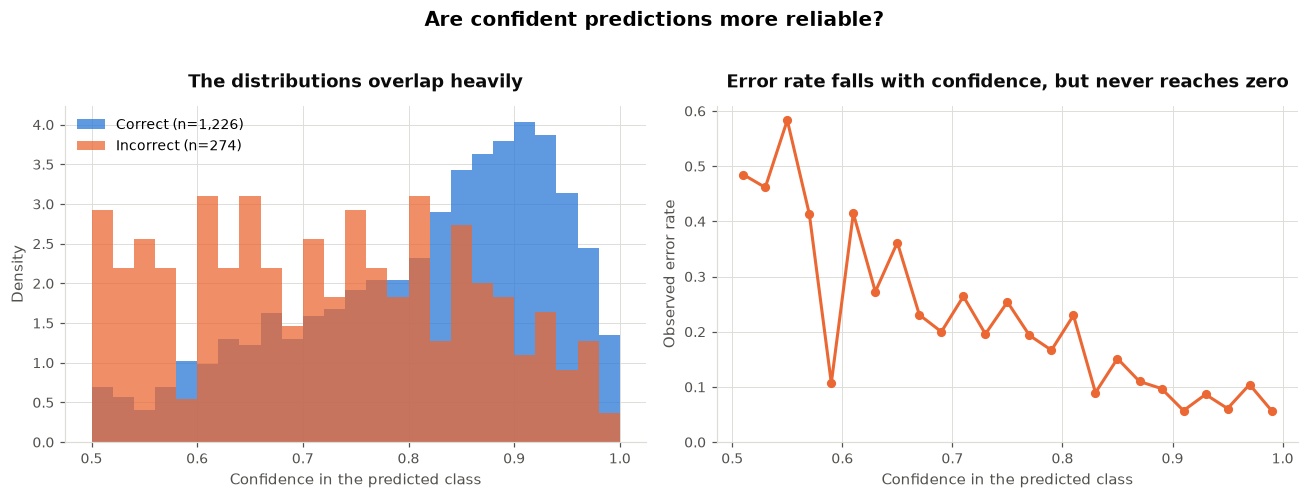

,Predictions,Of which wrong,False negatives,False positives
Confidence at least,,,,
0.80,847,89,87,2
0.90,393,29,29,0
0.95,143,12,12,0


In [27]:
prediction_confidence = confidence_of_prediction(random_forest_probability, DEFAULT_THRESHOLD)

display(summarise_confidence(class_target, random_forest_probability))
display(plot_confidence_distributions(prediction_confidence, is_correct.to_numpy()))
display(high_confidence_errors(class_target, random_forest_probability))

**Results.** Correct predictions carry a mean confidence of 0.815 against 0.722
for incorrect ones. The distributions are separated but overlap heavily, and the
error rate declines with confidence without ever reaching zero.

The high-confidence errors are where the finding is:

| Confidence at least | Predictions | Wrong | False negatives | False positives |
|---|---|---|---|---|
| 0.80 | 847 | 89 | 87 | **2** |
| 0.90 | 393 | 29 | **29** | **0** |
| 0.95 | 143 | 12 | **12** | **0** |

**Interpretation.** Confidence is informative but not sufficient. Filtering to
predictions the model backs at 90% or above removes 74% of the data and still
leaves 29 errors — a 7.4% error rate among the model's most confident calls. A
user who trusted high-confidence output would still be wrong roughly one time in
thirteen.

**The composition of those errors is the striking result. Every single one is a
false negative.** At 0.9 confidence there are 29 errors and zero false positives;
at 0.95, twelve errors and again none. The model is **never confidently wrong
about calling a game a standout — it is only ever confidently wrong about
dismissing one.**

That asymmetry has a clear mechanism. Because the negative class holds 75% of the
data, high confidence in the negative direction is cheap to obtain: a game with
unremarkable features looks like the 1,125 unremarkable games in the training
folds. High confidence in the positive direction is hard, and the model only
reaches it when the evidence is strong. The result is that its overconfidence is
concentrated entirely in the direction that section 4.2 identified as the more
expensive error.

### 4.4 Error as a Function of Features

**Method.** Feature distributions are compared between correctly and incorrectly
classified games, using a Mann-Whitney test because chapter 2 established that
these features are heavily skewed.

,Median when correct,Median when wrong,Mann-Whitney p
Feature,,,
price,14.99,19.99,1.9e-05
reviewScore,84.00,86.00,0.29
avgPlaytime,6.25,9.29,6.4e-13
daysOnSale,130.00,123.00,0.67
publisherReleaseCount,1.00,1.00,0.25
releaseMonth,5.00,5.00,0.74


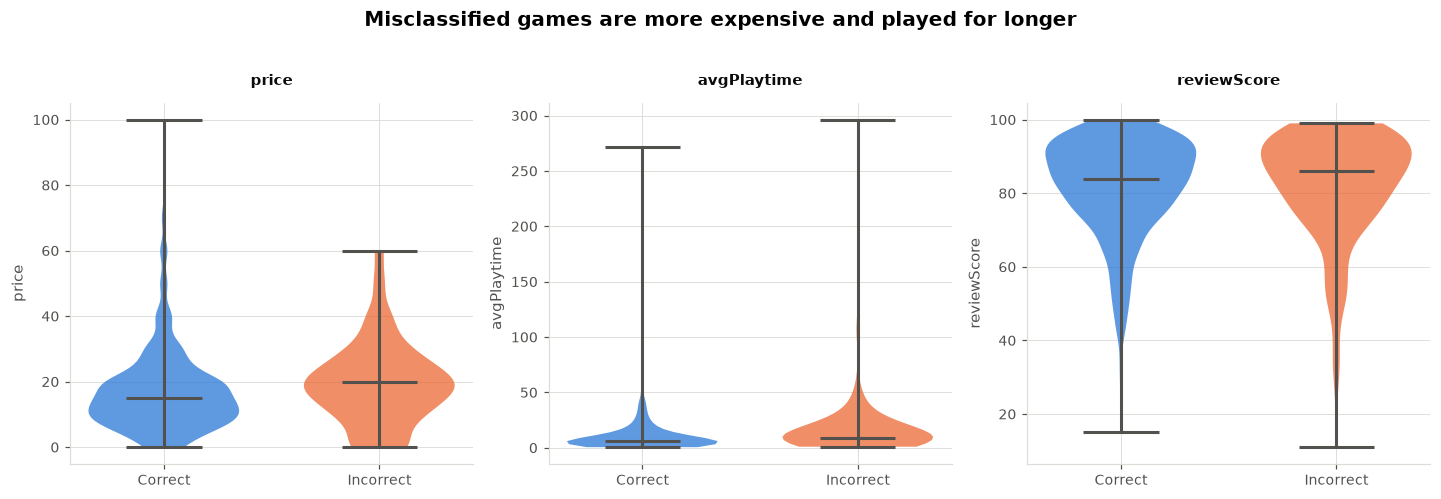

,Variable,Level,Games,Error rate
0,plotClass,Indie,1302,0.172
1,plotClass,AA,146,0.288
2,plotClass,AAA,52,0.154
3,priceBand,Free,85,0.353
4,priceBand,$0.01-9.99,417,0.089
5,priceBand,$10-19.99,629,0.176
6,priceBand,$20-39.99,304,0.273
7,priceBand,$40+,65,0.200
8,isFreeToPlay,False,1415,0.172
9,isFreeToPlay,True,85,0.353


In [28]:
display(compare_features_by_outcome(games, NUMERIC_FEATURES, is_correct))
display(plot_feature_outcome_distributions(games, ["price", "avgPlaytime", "reviewScore"], is_correct))

subgroup_error_rates = []
for column in ["plotClass", "priceBand", "isFreeToPlay"]:
    grouped = pd.DataFrame({column: games[column], "correct": is_correct}).groupby(column, observed=True)
    for level, group in grouped:
        subgroup_error_rates.append({
            "Variable": column,
            "Level": str(level),
            "Games": len(group),
            "Error rate": round(1 - group["correct"].mean(), 3),
        })
pd.DataFrame(subgroup_error_rates)

**Results.** Two features differ significantly between correct and incorrect
predictions, and four do not.

| Feature | Median when correct | Median when wrong | Mann-Whitney p |
|---|---|---|---|
| `avgPlaytime` | 6.25 | 9.29 | **6.4 × 10⁻¹³** |
| `price` | $14.99 | $19.99 | **1.9 × 10⁻⁵** |
| `reviewScore` | 84 | 86 | 0.29 |
| `daysOnSale` | 130 | 123 | 0.67 |
| `publisherReleaseCount` | 1 | 1 | 0.25 |
| `releaseMonth` | 5 | 5 | 0.74 |

By subgroup, the error rate is 0.353 for free-to-play games against 0.172 for
paid, 0.273 in the $20–39.99 band against 0.089 in $0.01–9.99, and 0.288 for AA
studios against 0.154 for AAA.

**Interpretation.** These are the same two features — `avgPlaytime` and `price` —
that predicted the size of the regression error in section 2.2, and the same
subgroups — free-to-play and expensive titles — that carried the highest
residuals. **The two models fail on the same games for the same reasons**, which
is evidence that the difficulty belongs to the data rather than to either
model's functional form.

The free-to-play result is the clearest instance. Their error rate is double the
paid rate in classification, exactly as their MAE was 38% higher in regression,
and the cause is the same: a listed price of zero says nothing about how the game
monetises, and the feature set contains nothing else that does.

The four non-significant features are worth noting too. `reviewScore` does not
distinguish correct from incorrect predictions, consistent with Assignment 1's
finding that review score is uncorrelated with commercial outcome and with
section 2.2's finding that it barely predicts regression error either.

### 4.5 Threshold Sensitivity Analysis

**Method.** Every threshold from 0.1 to 0.9 is evaluated, as the assignment
specifies, and precision, recall, F1 and MCC are computed at each.

,Predicted positive,TP,FP,FN,TN,Precision,Recall,F1,MCC
Threshold,,,,,,,,,
0.1,1116,346,770,29,355,0.310,0.923,0.464,0.236
0.2,694,288,406,87,719,0.415,0.768,0.539,0.354
0.3,455,239,216,136,909,0.525,0.637,0.576,0.419
0.4,283,187,96,188,1029,0.661,0.499,0.568,0.457
0.5,213,157,56,218,1069,0.737,0.419,0.534,0.458
0.6,143,114,29,261,1096,0.797,0.304,0.440,0.410
0.7,91,76,15,299,1110,0.835,0.203,0.326,0.343
0.8,41,39,2,336,1123,0.951,0.104,0.188,0.271
0.9,9,9,0,366,1125,1.000,0.024,0.047,0.135


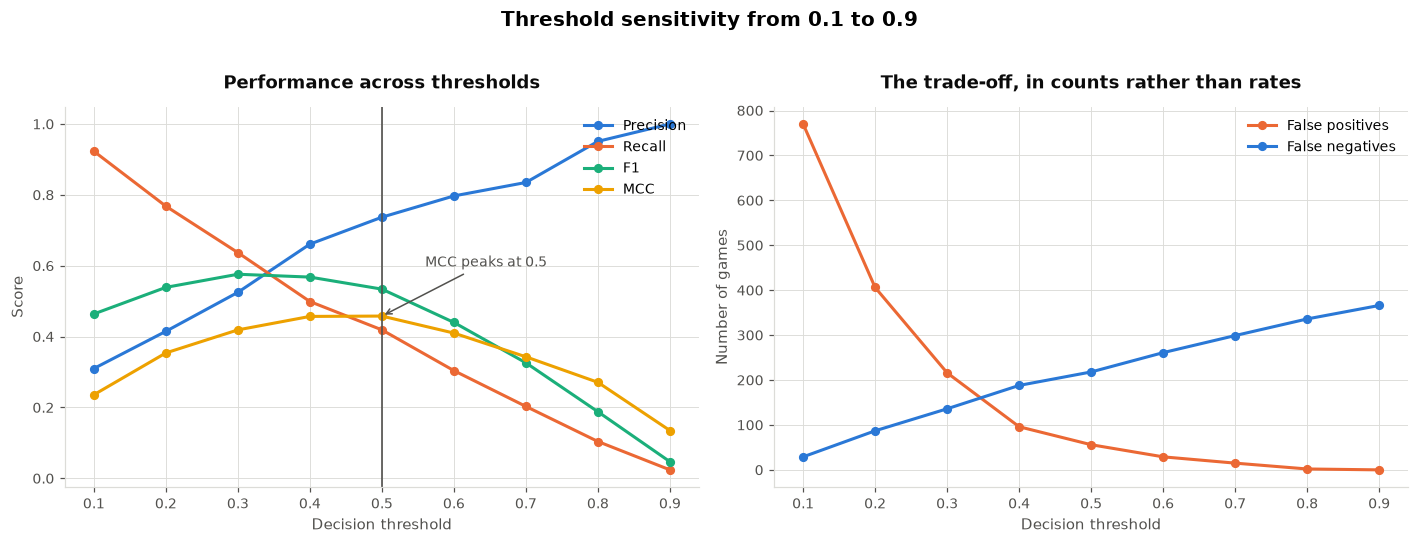

MCC is maximised at threshold 0.5 (MCC = 0.458)
F1  is maximised at threshold 0.3 (F1  = 0.576)


In [29]:
sweep = threshold_sweep(class_target, random_forest_probability)
display(sweep)
display(plot_threshold_curves(sweep))

print(f"MCC is maximised at threshold {sweep['MCC'].idxmax():.1f} (MCC = {sweep['MCC'].max():.3f})")
print(f"F1  is maximised at threshold {sweep['F1'].idxmax():.1f} (F1  = {sweep['F1'].max():.3f})")

**Results.**

| Threshold | TP | FP | FN | Precision | Recall | F1 | MCC |
|---|---|---|---|---|---|---|---|
| 0.1 | 346 | 770 | 29 | 0.310 | 0.923 | 0.464 | 0.236 |
| 0.2 | 288 | 406 | 87 | 0.415 | 0.768 | 0.539 | 0.354 |
| **0.3** | 239 | 216 | 136 | 0.525 | 0.637 | **0.576** | 0.419 |
| **0.4** | 187 | 96 | 188 | 0.661 | 0.499 | 0.568 | 0.457 |
| **0.5** | 157 | 56 | 218 | 0.737 | 0.419 | 0.534 | **0.458** |
| 0.6 | 114 | 29 | 261 | 0.797 | 0.304 | 0.440 | 0.410 |
| 0.7 | 76 | 15 | 299 | 0.835 | 0.203 | 0.326 | 0.343 |
| 0.8 | 39 | 2 | 336 | 0.951 | 0.104 | 0.188 | 0.271 |
| 0.9 | 9 | 0 | 366 | 1.000 | 0.024 | 0.047 | 0.135 |

**The false positive / false negative trade-off.** The right-hand panel shows
the two error counts crossing between thresholds 0.3 and 0.4. At 0.1 the model
raises 770 false alarms to catch 346 of the 375 standouts; at 0.9 it makes no
false alarms at all and catches nine. Every threshold in between buys recall with
precision at a rate that is far from constant.

**Stable and unstable operating regions.** The two summary metrics disagree
about the optimum — F1 peaks at 0.3 (0.576) and MCC at 0.5 (0.458) — and the
disagreement itself defines the stable region.

- **Stable: 0.3 to 0.5.** MCC varies only between 0.419 and 0.458 across this
  span, and F1 between 0.534 and 0.576. Moving the threshold within this band
  changes the precision–recall mix substantially — precision runs from 0.525 to
  0.737 — while overall discriminative quality barely moves. **This is the region
  where the threshold can be chosen on business grounds rather than statistical
  ones**, because the statistics are close to indifferent.
- **Unstable below 0.3.** At 0.2 the model predicts 694 positives against 375
  actual, and at 0.1 it predicts 1,116 — three times the true number. Precision
  collapses to 0.310 and MCC falls to 0.236. The model is barely discriminating.
- **Unstable above 0.6.** Recall collapses faster than precision improves. By 0.9
  the model achieves perfect precision on nine predictions and misses 366 of 375
  standouts, and MCC falls to 0.135. Perfect precision on 2.4% of the positive
  class is not a useful operating point.

**Interpretation.** The default threshold of 0.5 sits at the top of the stable
band and is defensible on MCC. But section 4.2 argued that false negatives are
the more expensive error here, and **at 0.5 the model produces 218 of them.**
Moving to 0.3 cuts false negatives to 136 — recovering 82 additional standouts —
at a cost of 160 extra false positives, while MCC falls only from 0.458 to 0.419.
Whether that is a good trade depends on the relative cost of the two errors,
which is exactly what $F_\beta$ formalises.

### 4.6 $F_\beta$, ROC and MCC

**Method.** $F_\beta$ generalises F1 by weighting recall $\beta$ times as
heavily as precision: $\beta < 1$ favours precision, $\beta > 1$ favours recall,
and $\beta = 1$ recovers F1. Rather than plotting $F_\beta$ at a single fixed
threshold, it is computed across the whole threshold grid, because the
operationally useful question is not how the score changes but **which threshold
one should choose given how much recall is worth**.

,beta=0.25,beta=0.5,beta=1,beta=2,beta=3,beta=4
Threshold,,,,,,
0.1,0.323,0.358,0.464,0.661,0.770,0.827
0.2,0.427,0.457,0.539,0.656,0.708,0.731
0.3,0.531,0.544,0.576,0.611,0.624,0.629
0.4,0.648,0.620,0.568,0.524,0.511,0.506
0.5,0.706,0.640,0.534,0.458,0.438,0.430
0.6,0.728,0.602,0.440,0.347,0.324,0.315
0.7,0.706,0.514,0.326,0.239,0.219,0.212
0.8,0.643,0.362,0.188,0.127,0.114,0.110
0.9,0.295,0.109,0.047,0.030,0.027,0.025


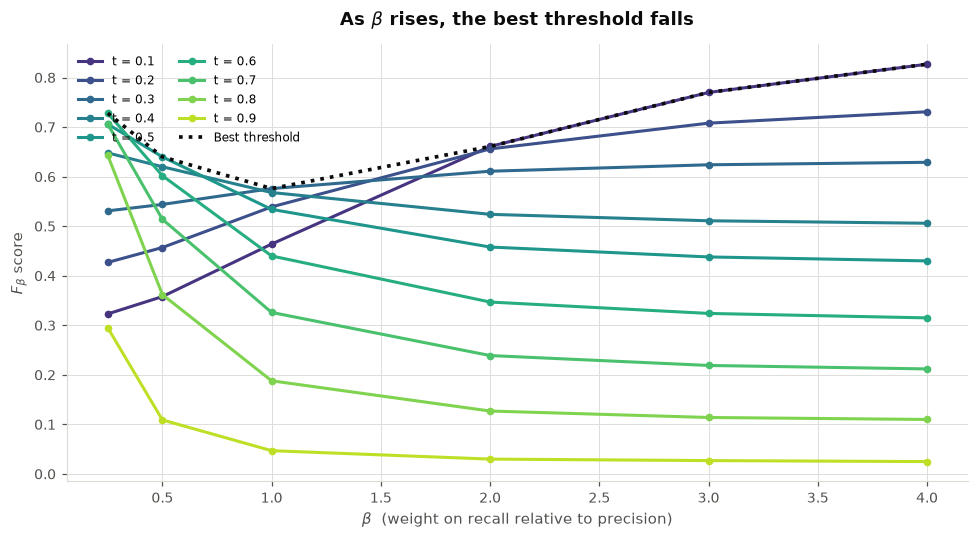

Threshold that maximises F-beta, for each beta:
   beta=0.25  ->  threshold 0.6
    beta=0.5  ->  threshold 0.5
      beta=1  ->  threshold 0.3
      beta=2  ->  threshold 0.1
      beta=3  ->  threshold 0.1
      beta=4  ->  threshold 0.1


In [30]:
beta_grid = fbeta_grid(class_target, random_forest_probability)
display(beta_grid)
display(plot_fbeta_curves(beta_grid))

optimal = {column: beta_grid[column].idxmax() for column in beta_grid.columns}
print("Threshold that maximises F-beta, for each beta:")
for name, threshold in optimal.items():
    print(f"  {name:>10}  ->  threshold {threshold:.1f}")

**Results and interpretation.** The curves cross, and where they cross is the
finding.

| β | Interpretation | Best threshold |
|---|---|---|
| 0.25 | Precision matters four times as much | 0.6 |
| 0.5 | Precision matters twice as much | 0.5 |
| 1 | Equal weight (F1) | 0.3 |
| 2 | Recall matters twice as much | 0.1 |
| 3–4 | Recall dominates | 0.1 |

**As $\beta$ rises the optimal threshold falls**, monotonically and steeply. A
decision-maker who considers missing a standout twice as costly as backing a dud
should operate at 0.1, not 0.5 — a completely different model behaviour obtained
from identical predictions.

This makes concrete the argument in section 4.2. If false negatives really are
the expensive error in this setting, the default threshold is not merely
suboptimal but **wrong by four increments of the grid.** The plot is the bridge
between a statistical choice and a business one.

A caution on reading it: at high $\beta$ the score becomes easy to inflate. At
$\beta = 4$ and threshold 0.1 the $F_\beta$ of 0.827 looks excellent, but that
operating point flags 1,116 of 1,500 games as standouts. $F_\beta$ with a large
$\beta$ rewards recall so heavily that near-indiscriminate prediction scores
well, which is why MCC — which uses all four cells of the confusion matrix — is
the better single summary.

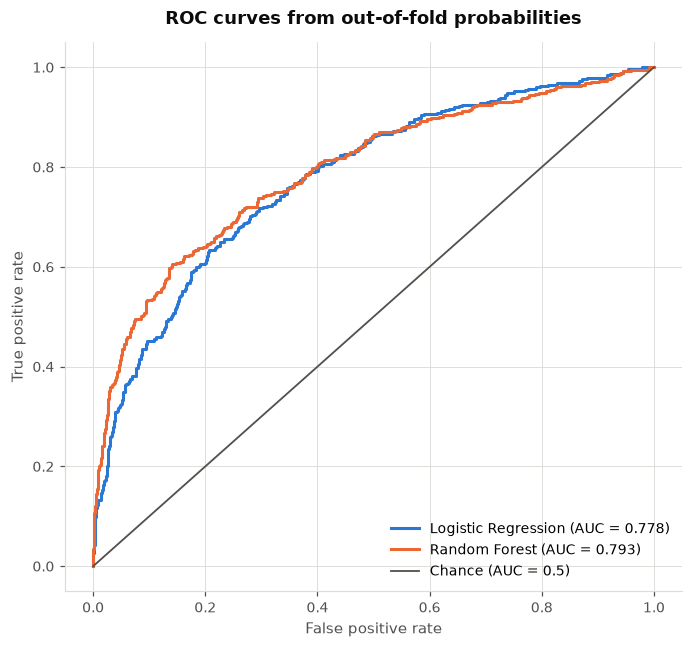

Logistic Regression    ROC-AUC = 0.7782
Random Forest          ROC-AUC = 0.7934


In [31]:
roc_curves = {
    name: (*roc_curve(class_target, probability)[:2], roc_auc_score(class_target, probability))
    for name, probability in class_probabilities.items()
}
display(plot_roc_curves(roc_curves))

for name, probability in class_probabilities.items():
    print(f"{name:22} ROC-AUC = {roc_auc_score(class_target, probability):.4f}")

**ROC and AUC.** The Random Forest achieves an AUC of **0.793** against 0.778 for
Logistic Regression. Both curves sit well above the diagonal, so both models
carry real discriminative signal.

**The AUC is the key to interpreting everything above.** An AUC of 0.793 means
that if one standout and one non-standout are drawn at random, the model assigns
the standout a higher probability 79% of the time. **The model ranks games well;
it classifies them poorly.** Those are different capabilities, and the gap
between them is entirely a threshold question — which is why section 4.5 mattered
so much and why the 0.5 default was worth challenging.

It also bounds what better tuning could achieve. AUC is threshold-independent, so
no choice of threshold raises it. Improving beyond 0.793 requires better features
or a better model, not a better cut point.

**On MCC.** MCC is reported throughout in preference to accuracy because it uses
all four confusion-matrix cells and is not inflated by a large true-negative
count. Its peak of 0.458 at threshold 0.5 corresponds to moderate agreement —
substantially better than chance (0) but far from the perfect 1. Reporting
accuracy of 81.7% instead would have overstated the model's ability by
comparison with the 75.0% floor.

### 4.7 Classification Discussion

**Strengths and limitations of the models in relation to the data.** Both
classifiers extract genuine signal: AUCs of 0.778 and 0.793 are well above
chance, and precision at the default threshold is around 0.7. The Random Forest
leads on every metric and by a wider relative margin than in the regression
comparison — MCC 0.458 against 0.372 — which suggests the class boundary is
genuinely non-linear in these features. The limitation is that neither model
converts good ranking into good classification, and neither can separate games
close to the boundary.

**Key failure modes.** Three were identified, and they compound.

1. **Failure concentrated at the class boundary.** Error rates of 0.013–0.093 in
   the bottom seven deciles against 0.660 in decile 9. The model is nearly
   perfect where the answer is obvious and near-random where it is not.
2. **Systematic under-detection of the positive class.** 218 false negatives
   against 56 false positives, and recall of only 0.419 — the error type section
   4.2 identified as the more costly.
3. **Overconfidence in exactly one direction.** All 29 high-confidence errors are
   false negatives, and there are no high-confidence false positives at all.

**The relationship between assumptions and observed performance.** Logistic
Regression assumes the log-odds are linear in the features; the Random Forest's
larger margin here than in the regression task suggests that assumption is more
costly for the classification boundary than the linearity assumption was for the
continuous target. Neither model assumes the classes are separable, and they are
not — the overlap around the threshold is a property of the data. The class
imbalance interacts with the default threshold to produce the conservatism seen
throughout, and that is a consequence of the decision rule rather than of either
model's assumptions.

**The most significant insight.** **The model's difficulty is not that it cannot
rank games, but that the question it was asked has no sharp answer.** An AUC of
0.793 alongside a recall of 0.419 is the signature of a model with usable
ordering and a badly chosen cut point — and part of the problem is that the cut
point is artificial. Section 0.3 defined "standout" as the 75th percentile of
revenue, a choice made for analytical convenience. Games at $450,000 and $460,000
are assigned opposite labels while being indistinguishable in every feature. A
substantial share of the errors in deciles 8 and 9 are, in a real sense, errors
of the problem formulation rather than of the model.

**Recommendations for improvement.** In descending order of expected value:

1. **Reconsider the target.** If the underlying question is "how commercially
   successful will this game be", the regression formulation in chapters 2–3
   answers it without imposing an arbitrary cut. If a binary decision really is
   required, a wider margin — top 10% against bottom 50%, discarding the
   ambiguous middle — would produce a better-posed problem.
2. **Move the threshold, and justify it from costs.** Section 4.6 shows the
   optimum ranges from 0.1 to 0.6 depending on how false negatives are valued.
   This costs nothing to implement and has more effect than any modelling change
   available here.
3. **Add features that separate the boundary cases.** Genre, wishlist counts,
   marketing spend and franchise history are the obvious candidates, and section
   4.4 shows the current features are exhausted.
4. **Add a missingness indicator for `reviewScore`**, carried over from section
   2.1, where median imputation was shown to bias predictions for those 99 games.
5. **Consider class weighting** as an alternative to threshold tuning, which
   addresses the imbalance during fitting rather than after it.

**Conclusion.** The Random Forest is a competent ranker and a poor classifier at
its default threshold. Its errors are concentrated where the artificial class
boundary cuts through a continuum, and they fall almost entirely on the expensive
side of an asymmetric cost structure. Both problems are addressable — one by
choosing a threshold deliberately, the other by reformulating the question.

## 5. Final Reflection

**Method.** This chapter introduces no new analysis. It answers the four
questions the assignment closes with, drawing only on results established in
chapters 1 to 4. The cell below recomputes each figure quoted here directly from
the objects those chapters produced, so no number in the discussion can drift
from what the notebook actually generated.

In [32]:
random_forest_regression = games[REGRESSION_TARGET] - model_predictions["Random Forest"]
hardest_regression = errors["absError"] >= errors["absError"].quantile(0.95)
free_to_play = games["isFreeToPlay"]

evidence = pd.DataFrame(
    [
        ("Regression: variance explained (Random Forest)",
         f"R2 = {metrics_table.loc['Random Forest', 'R2']:.4f}", "3.4"),
        ("Regression: typical error, as a dollar factor",
         f"x{metrics_table.loc['Random Forest', 'Median error factor']:.2f}", "3.4"),
        ("Regression: MAE on the hardest 5% of games",
         f"{random_forest_regression[hardest_regression].abs().mean():.3f} log units "
         f"(a factor of {10 ** random_forest_regression[hardest_regression].abs().mean():.0f})", "3.4"),
        ("Regression: ensemble gain over the linear baseline",
         f"{metrics_table.loc['Random Forest', 'R2'] - metrics_table.loc['Linear Regression', 'R2']:+.3f} R2", "3.4"),
        ("Regression: bias introduced by imputing reviewScore",
         f"{errors.loc[errors['reviewScore'].isna(), 'residual'].mean():+.3f} log units", "2.1"),
        ("Classification: ranking quality",
         f"AUC = {roc_auc_score(class_target, random_forest_probability):.3f}", "4.6"),
        ("Classification: recall at the default threshold",
         f"{sweep.loc[0.5, 'Recall']:.3f}", "4.5"),
        ("Classification: accuracy against the majority-class floor",
         f"0.817 vs {(class_target == 0).mean():.3f}", "4.1"),
        ("Classification: error rate at the class boundary (decile 9)",
         f"{decile_errors.loc[9, 'Error rate']:.3f}", "4.2"),
        ("Classification: error rate away from it (deciles 1-7)",
         f"{decile_errors.loc[1:7, 'Error rate'].max():.3f} at worst", "4.2"),
        ("Both tasks: free-to-play penalty",
         f"regression MAE {errors.loc[free_to_play, 'absError'].mean() / errors.loc[~free_to_play, 'absError'].mean():.2f}x, "
         f"classification error rate {(1 - is_correct[free_to_play].mean()) / (1 - is_correct[~free_to_play].mean()):.2f}x", "2.1, 4.4"),
    ],
    columns=["Evidence", "Value", "Section"],
)
evidence

,Evidence,Value,Section
0,Regression: variance explained (Random Forest),R2 = 0.3495,3.4
1,"Regression: typical error, as a dollar factor",x2.46,3.4
2,Regression: MAE on the hardest 5% of games,1.277 log units (a factor of 19),3.4
3,Regression: ensemble gain over the linear base...,+0.064 R2,3.4
4,Regression: bias introduced by imputing review...,+0.300 log units,2.1
5,Classification: ranking quality,AUC = 0.793,4.6
6,Classification: recall at the default threshold,0.419,4.5
7,Classification: accuracy against the majority-...,0.817 vs 0.750,4.1
8,Classification: error rate at the class bounda...,0.660,4.2
9,Classification: error rate away from it (decil...,0.093 at worst,4.2


### 1. Where does the model fail most?

**In three places, and they turn out to be the same place seen from different
angles.**

**At the top of the revenue distribution.** The regression's largest 5% of errors
are 75 games carrying 16.5% of all absolute error, of which 60 are
under-predictions. These are not anomalous records — they are the year's biggest
titles. The Random Forest predicts $6.2M for *Black Myth: Wukong*, which earned
$838M, and its MAE on this group is 1.277 log units: a factor of nineteen, after
the ensemble has already improved it from a factor of forty-one.

**At the classification boundary.** Error rates run from 0.013 in the lowest
revenue decile to **0.660 in decile 9**, immediately above the $455,157 cut. The
model is close to perfect on the bottom 70% of the distribution and worse than a
coin flip just above the threshold.

**On free-to-play titles and expensive titles, in both tasks simultaneously.**
Free-to-play games carry 1.38 times the regression error and 2.05 times the
classification error rate. `avgPlaytime` and `price` are the only two features
that predict error size in the regression (ρ = 0.216 and 0.176) and the only two
that separate correct from incorrect classifications (p = 6×10⁻¹³ and 2×10⁻⁵).

**That convergence is the finding.** Two different model families, two different
target formulations, one continuous and one binary — and both fail on the same
games, identified by the same features. When independent approaches fail
identically, the difficulty is unlikely to belong to either of them.

### 2. Are the failures due to data, the model, or the problem formulation?

**All three contribute, but in a specific and unequal order. The evidence
supports ranking them.**

#### Problem formulation — the largest contributor

Three formulation decisions shaped the results more than any modelling choice.

**The sample was selected on the target.** These 1,500 games are the top earners
of 2024, chosen on revenue, which both tasks then try to predict. Assignment 1
showed this erases the relationship between exposure and revenue, and section 2.2
confirmed it here: `daysOnSale` has a rank correlation of −0.027 with the error
and 0.043 with the target. A variable that should matter a great deal cannot,
because the selection removed its effect.

**The class boundary is an artefact.** "Standout" is the 75th percentile — a line
drawn for analytical convenience. Games at $450,000 and $460,000 receive opposite
labels while being indistinguishable in every recorded feature. The error rate of
0.660 in decile 9 against at most 0.093 in deciles 1–7 is the direct cost of
that. A large share of the classifier's mistakes are not mistakes about games;
they are mistakes about a line.

**Withholding `copiesSold` capped the achievable R².** Section 1.3 measured the
alternative at 0.927 and rejected it, because the coefficients of 0.988 and 1.005
showed the model was recovering the accounting identity `revenue = copies ×
price` rather than learning anything. This was a deliberate choice and it is not
a defect — but it is the reason R² is 0.35 rather than 0.93, and honesty requires
naming it as a formulation decision rather than a modelling failure.

#### Data — the second contributor

**The features do not contain what determines commercial success.** The dataset
records price, playtime, review score, studio class and release timing. It
records nothing about marketing spend, franchise recognition, wishlist counts,
genre, streamer coverage or word of mouth. Those are what separate a title
selling fifteen million copies from one selling fifty thousand, and no model can
recover information that is absent.

**Free-to-play games have no usable price signal.** For 85 titles the listed
price is zero and revenue arrives through in-game purchases the data does not
describe. Their error is roughly double in both tasks, which is what a missing
mechanism looks like.

**One data problem was self-inflicted and is fixable.** Imputing the median
review score for the 99 placeholder rows biased their predictions by **+0.300 log
units** — a systematic factor-of-two under-prediction — because Assignment 1
showed that group earns above average rather than typically. That is a
consequence of a choice made in section 1.5, not a property of the data, and
section 5.3 proposes the remedy.

#### The model — the smallest contributor

This is the conclusion I did not expect at the outset, and the evidence for it is
the strongest in the notebook.

**Changing the model family barely helps.** Moving from ordinary least squares to
a 300-tree ensemble raised R² from 0.286 to **0.350**, a gain of 0.064 — roughly
one fold-standard-deviation — and it disappeared entirely under modest label
noise. On the hardest 75 games, the same change improved MAE from 1.616 to 1.277:
from a factor of forty-one wrong to a factor of nineteen wrong.

**The linear model's assumptions genuinely are violated** — section 2.1
established heteroscedasticity with the residual standard deviation doubling
across the prediction range, and rejected normality at p ≈ 10⁻³⁴. Those
violations are real. But the tree-based models make none of those assumptions and
gained only 0.064 R², which bounds how much the violations were costing.

**Where the model was clearly at fault, the fix was easy.** The unbounded decision
tree scored a training R² of 1.000 and an out-of-fold R² of −0.235. That is a
pure modelling failure, and constraining depth to 3 resolved it completely.

**Conclusion.** Ranked by contribution: **formulation, then data, then model.**
The practical implication is that further modelling effort on this feature set is
close to exhausted, and the returns lie in changing the question or enriching the
inputs.

### 3. What improvements would I propose?

Ordered by expected value, with the evidence that motivates each.

**1. Add features that describe demand rather than the product.** The single
highest-value change. Genre, wishlist counts before launch, marketing spend,
franchise history and streamer coverage would address the dominant failure — the
blockbusters the model cannot see coming. Motivated by section 3.4, where a
change of model family moved the hardest cases by only a factor of two.

**2. Recover the review count.** Assignment 1 established that the vendor's
revenue estimates are derived from review counts, which the file withholds while
publishing the estimate. Adding it would improve the model and, more importantly,
allow the target's own reliability to be assessed. Currently every error is a
mixture of model error and estimation error, and nothing here can separate them.

**3. Reformulate the classification target.** The error rate of 0.660 at the
boundary is largely an artefact of imposing a cut on a continuum. Either drop the
binary framing — chapters 2 and 3 answer the underlying question without it — or
widen the margin, predicting the top 10% against the bottom 50% and discarding
the ambiguous middle. That produces a better-posed problem rather than a better
model for a poorly posed one.

**4. Choose the decision threshold from costs, not convention.** Section 4.6
showed the $F_\beta$-optimal threshold moving from 0.6 to 0.1 as the weight on
recall rises. If a missed standout costs twice a false alarm, the correct
threshold is 0.1 and the default of 0.5 leaves 82 recoverable standouts
undetected. This costs nothing to implement and has more effect than any model
change available.

**5. Add a missingness indicator for `reviewScore`.** A one-line change that
addresses the +0.300 bias measured in section 2.1, by letting the model learn
that an absent review score is itself informative rather than treating those
games as average.

**6. Model free-to-play titles separately.** Their revenue arises through a
mechanism the features do not describe, and pooling them with paid games forces
one model to serve two processes. A separate model, or an interaction term, would
at least isolate the damage.

**7. Obtain the unselected population.** Every conditional statement in this
notebook exists because the sample is the top 1,500 earners. A full census of
2024 Steam releases would remove the survivorship constraint and let the exposure
effect be estimated rather than merely acknowledged.

The first two address the dominant cause. Items 3 to 6 are cheap and immediate.
Item 7 is the most valuable and the least available.

### 4. What insights did I gain from the analysis?

**A metric can be excellent and worthless.** The most instructive result came
before any model comparison. Including `copiesSold` produced an R² of 0.927 — a
number that would look strong in any report — while the model was recovering an
accounting identity with coefficients of 0.988 and 1.005. The excess kurtosis of
27.7 was the only clue in the metrics that something was wrong. Had I trusted the
headline figure, the entire error analysis would have been an analysis of one
arithmetic rule and its 85 free-to-play exceptions.

**Out-of-fold evaluation is not a formality.** The unbounded decision tree fitted
its training data perfectly and predicted worse than a constant. On training
scores alone it was the best model in the comparison; out of fold it was the
worst by a wide margin. The assignment's insistence that all analysis use k-fold
cross-validation is not procedural strictness — it is the only thing separating
those two conclusions.

**Ranking and classifying are different capabilities.** An AUC of 0.793 alongside
a recall of 0.419 initially read as a contradiction. It is not: the model orders
games well and cuts them badly. Recognising this changed what the remedy was —
not a better model, but a better threshold, chosen from costs rather than
inherited from a default.

**Error analysis finds things aggregate metrics cannot.** The +0.300 bias on
games with missing review scores does not appear in MAE, RMSE or R². It appears
only when the residuals are grouped by a variable that is not in the model. It
was caused by my own imputation choice, and I would not have found it by
comparing model scores.

**Confidence has a direction.** All 29 of the classifier's high-confidence errors
are false negatives and none is a false positive. The model is never confidently
wrong about identifying a standout, only about dismissing one — and that is the
expensive direction. A single overall calibration figure would have concealed
this entirely.

**Convergent failure is diagnostic.** The most useful signal in the whole notebook
was that two model families, on two differently-formulated targets, failed on the
same games and were betrayed by the same two features. Individually each result
is a modelling observation; together they are evidence about the data, and they
are what justifies the conclusion in section 5.2 that the model is the smallest
of the three contributors.

**Finally, on what the numbers mean.** An R² of 0.35 and a recall of 0.42 are
weak by most standards, and it would be easy to present them apologetically. But
the assignment's framing — that the purpose is to understand *where* and *why*
models fail — makes them the right results to have. A model that scored 0.93 by
rediscovering `revenue = copies × price` would have taught nothing. The
comparatively poor model, whose errors are traceable to an absent feature set, an
artificial class boundary and a sample selected on its own target, is the one
that supported an analysis.